In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import scipy as scipy
import math as math

plt.style.use('thesis_b5')
full_width, full_height = plt.rcParams['figure.figsize']

In [22]:
path_load = "results_data/hyperparameter_sweep_v2/"

In [23]:
palette_colors_curvature = {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'}
#palette_colors_curvature = {'BFc':'blue','BFc_3':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'}

# Hyperparameter distributions & Analysis (Full)

## Loading Data GraphSAGE & GAT

In [18]:
dataset_names_GAT_GraphSAGE = ['Texas','Cora','Chameleon']
curvature_types = ['BFc','BFc_3','BFc_mod','JLc','AFc_3','AFc_4','None']


### GraphSAGE

In [24]:
dict_classification_datasets_GraphSAGE = {}
dict_classification_datasets_meanaccuracy_GraphSAGE = {}
dict_classification_datasets_meanaccuracy_top_GraphSAGE = {}

top_x_considered = 100

for dataset_name in dataset_names_GAT_GraphSAGE:#dataset_names:
    dictionary_dataset = {}
    dictionary_dataset_meanaccuracy = {}
    dictionary_dataset_meanaccuracy_top = {}
    for curvature_type in curvature_types:
        #dataset = pd.read_csv(f"{path_load}/time_runs/{dataset_name}_{curvature_type}_time.csv",nrows = 1000)
        dataset = pd.read_csv(f"{path_load}/{dataset_name}_{curvature_type}_GraphSAGE.csv",nrows = 1000)
        dataset =dataset.loc[dataset['learning_rate'] < 0.01].reset_index(drop=True)
        dictionary_dataset[curvature_type] = dataset

        mean_accuracy = dataset['mean test accuracy']
        #mean_accuracy = dataset['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy[curvature_type] = mean_accuracy

        mean_accuracy_top = mean_accuracy.sort_values(ascending = False)[:top_x_considered].reset_index(drop=True)
        #mean_accuracy_top = dataset.loc[dataset['E[final_test_accuracy]']> 0.20*1.05]['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy_top[curvature_type] = mean_accuracy_top

    dict_classification_datasets_GraphSAGE[dataset_name] = dictionary_dataset
    dict_classification_datasets_meanaccuracy_GraphSAGE[dataset_name] = dictionary_dataset_meanaccuracy
    dict_classification_datasets_meanaccuracy_top_GraphSAGE[dataset_name] = dictionary_dataset_meanaccuracy_top

In [25]:
dataset

,Name,Agent,State,Notes,User,Tags,Created,Runtime,Sweep,C+,...,parameters.tau.distribution,parameters.tau.max,parameters.tau.min,parameters.weight_decay.distribution,parameters.weight_decay.max,parameters.weight_decay.min,tau,weight_decay,mean accuracy,mean test accuracy
0,rich-sweep-1160,NaN,finished,-,NaN,NaN,2024-11-15T05:20:11.000Z,58,70hrh4oi,18.896680,...,NaN,NaN,NaN,NaN,NaN,NaN,191,0.119813,0.353293,0.416766
1,dutiful-sweep-958,NaN,finished,-,NaN,NaN,2024-11-15T01:01:22.000Z,72,70hrh4oi,18.927259,...,NaN,NaN,NaN,NaN,NaN,NaN,294,0.514620,0.248144,0.308263
2,pleasant-sweep-952,NaN,finished,-,NaN,NaN,2024-11-15T00:52:48.000Z,100,70hrh4oi,8.642479,...,NaN,NaN,NaN,NaN,NaN,NaN,223,0.030083,0.413713,0.478982
3,sage-sweep-950,NaN,finished,-,NaN,NaN,2024-11-15T00:49:41.000Z,112,70hrh4oi,20.817743,...,NaN,NaN,NaN,NaN,NaN,NaN,17,0.026027,0.402156,0.454790
4,glowing-sweep-836,NaN,finished,-,NaN,NaN,2024-11-14T22:24:15.000Z,68,70hrh4oi,13.044825,...,NaN,NaN,NaN,NaN,NaN,NaN,314,0.180042,0.241796,0.288862
5,lilac-sweep-792,NaN,finished,-,NaN,NaN,2024-11-14T21:27:31.000Z,64,70hrh4oi,5.004856,...,NaN,NaN,NaN,NaN,NaN,NaN,175,0.452951,0.236766,0.287665
6,absurd-sweep-753,NaN,finished,-,NaN,NaN,2024-11-14T20:39:31.000Z,52,70hrh4oi,11.896389,...,NaN,NaN,NaN,NaN,NaN,NaN,95,0.452729,0.247126,0.307485
7,dulcet-sweep-743,NaN,finished,-,NaN,NaN,2024-11-14T20:28:18.000Z,62,70hrh4oi,2.407472,...,NaN,NaN,NaN,NaN,NaN,NaN,103,0.345468,0.248144,0.308263
8,devout-sweep-636,NaN,finished,-,NaN,NaN,2024-11-14T18:04:58.000Z,111,70hrh4oi,17.912632,...,NaN,NaN,NaN,NaN,NaN,NaN,285,0.016088,0.394790,0.442994
9,youthful-sweep-611,NaN,finished,-,NaN,NaN,2024-11-14T17:31:52.000Z,62,70hrh4oi,11.363014,...,NaN,NaN,NaN,NaN,NaN,NaN,66,0.466793,0.248144,0.308263


In [26]:
for dataset_name in dataset_names_GAT_GraphSAGE:#dataset_names:
    mean_accuracy_top = pd.DataFrame(dict_classification_datasets_meanaccuracy_top_GraphSAGE[dataset_name]) #dictionary_all_mean_accuracy_top[dataset_name]
    print(f"=============={dataset_name}================\n")
    mean_std_top = pd.DataFrame({'mean':np.round(mean_accuracy_top.mean()*100,2),'std':np.round(mean_accuracy_top.std()*100,2)})
    print(mean_std_top.T)
    print("\n")
    print(pd.DataFrame(dict_classification_datasets_meanaccuracy_top_GraphSAGE[dataset_name]).median())


==============Texas================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  60.24  61.09    62.20  61.47  63.79  62.19  63.68
std    3.25   3.87     4.69   4.19   5.68   4.69   8.26


BFc        0.592593
BFc_3      0.592593
BFc_mod    0.593333
JLc        0.592593
AFc_3      0.596296
AFc_4      0.593333
None       0.592593
dtype: float64
==============Cora================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  19.85  33.33    14.04  29.27  27.24  26.58  22.81
std   14.30  25.84     0.90  21.94  18.28  17.26  22.53


BFc        0.147482
BFc_3      0.183640
BFc_mod    0.140589
JLc        0.149817
AFc_3      0.154690
AFc_4      0.177868
None       0.142508
dtype: float64
==============Chameleon================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  32.02  32.18    31.27  30.62  33.54  31.85  35.90
std    5.58   4.07     1.82   0.51   5.49   4.01   7.85


BFc        0.307874
BFc_3      0.308263
BFc_mod    0.308263
JLc   

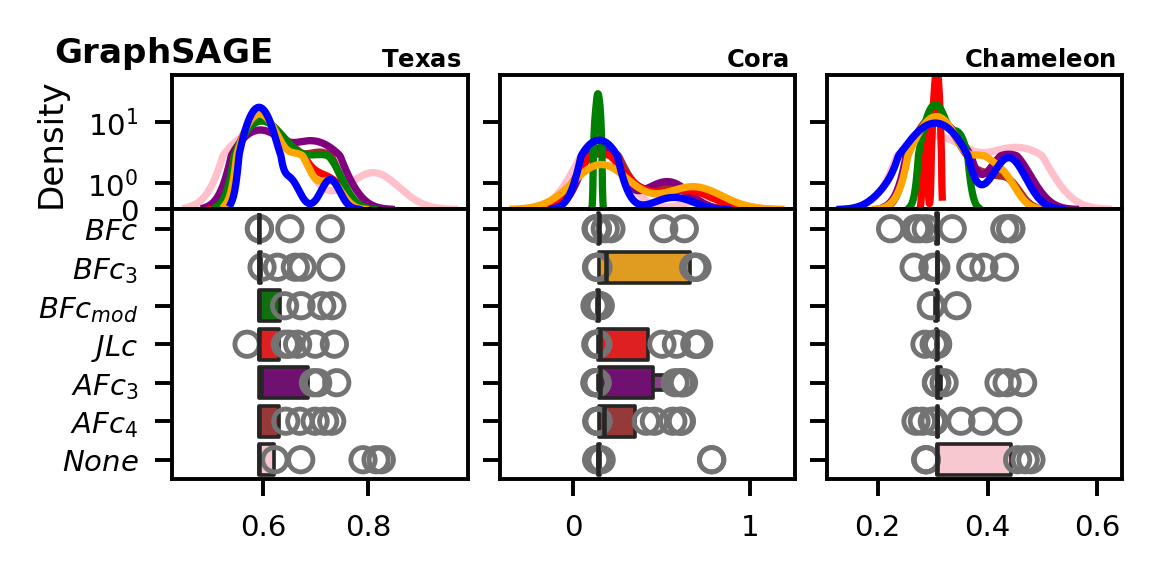

In [27]:
figTotal, axTotal = plt.subplot_mosaic([['Dens_Texas','Dens_Texas','Dens_Texas','.','Dens_Cora','Dens_Cora','Dens_Cora','.','Dens_Chameleon','Dens_Chameleon','Dens_Chameleon'],
                                        ['BP_Texas','BP_Texas','BP_Texas','.','BP_Cora','BP_Cora','BP_Cora','.','BP_Chameleon','BP_Chameleon','BP_Chameleon']],figsize = (3.5,1.5),dpi = 350,
                             gridspec_kw = {'width_ratios': [0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5] ,'height_ratios': [0.5,1],'hspace': 0})

right = 0.98
top = 1.2
left = 0.08

axTotal[f'Dens_Texas'].text(-0.4, 1.3,
                        horizontalalignment='left',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_Texas'].transAxes,s = r"$\mathbf{GraphSAGE}$",fontsize = 7)


for dataset_name in dataset_names_GAT_GraphSAGE:
    #if dataset_name in ["Texas","Cornell","Wisconsin"]:
    axTotal[f'Dens_{dataset_name}'].text(right, top,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_{dataset_name}'].transAxes,s = r"$\mathbf{"+dataset_name+"}$",fontsize = 5)



    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy_top_GraphSAGE[dataset_name],ax = axTotal[f'Dens_{dataset_name}'],palette= palette_colors_curvature,legend=False,common_norm=False,log_scale=(False,True))

    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy_top_GraphSAGE[dataset_name],ax = axTotal[f'BP_{dataset_name}'],orient = "y",palette=palette_colors_curvature,legend=False)

    axTotal[f'BP_{dataset_name}'].set_xlabel("",fontsize = 7)
    axTotal[f'Dens_{dataset_name}'].set_xlabel("",fontsize = 7)

    axTotal[f'Dens_{dataset_name}'].set_yscale("symlog")
    axTotal[f'Dens_{dataset_name}'].tick_params(labelsize = 6)
    axTotal[f'BP_{dataset_name}'].tick_params(labelsize = 6)
    

    if dataset_name in ["Texas"]:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("Density",fontsize = 7)
        axTotal[f'Dens_{dataset_name}'].set_ylim(0,95)
        axTotal[f'BP_{dataset_name}'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$",r"$None$"])
    else:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("",fontsize = 7)

    _ = axTotal[f'BP_{dataset_name}'].sharex(axTotal[f'Dens_{dataset_name}'])   
    _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_xticklabels()]
    

    if dataset_name not in ["Texas"]:
        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
        


figTotal.savefig("results_figures/hyperparameter_sweep_total_GraphSAGE.pdf",bbox_inches='tight')

### GAT

In [28]:
dict_classification_datasets_GAT = {}
dict_classification_datasets_meanaccuracy_GAT = {}
dict_classification_datasets_meanaccuracy_top_GAT = {}

top_x_considered = 100

for dataset_name in dataset_names_GAT_GraphSAGE:#dataset_names:
    dictionary_dataset = {}
    dictionary_dataset_meanaccuracy = {}
    dictionary_dataset_meanaccuracy_top = {}
    for curvature_type in curvature_types:
        #dataset = pd.read_csv(f"{path_load}/time_runs/{dataset_name}_{curvature_type}_time.csv",nrows = 1000)
        dataset = pd.read_csv(f"{path_load}/{dataset_name}_{curvature_type}_GAT.csv",nrows = 1000)
        dataset = dataset.loc[dataset['learning_rate'] < 0.01].reset_index(drop=True)
        dictionary_dataset[curvature_type] = dataset

        mean_accuracy = dataset['mean test accuracy']
        #mean_accuracy = dataset['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy[curvature_type] = mean_accuracy

        mean_accuracy_top = mean_accuracy.sort_values(ascending = False)[:top_x_considered].reset_index(drop=True)
        #mean_accuracy_top = dataset.loc[dataset['E[final_test_accuracy]']> 0.20*1.05]['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy_top[curvature_type] = mean_accuracy_top

    dict_classification_datasets_GAT[dataset_name] = dictionary_dataset
    dict_classification_datasets_meanaccuracy_GAT[dataset_name] = dictionary_dataset_meanaccuracy
    dict_classification_datasets_meanaccuracy_top_GAT[dataset_name] = dictionary_dataset_meanaccuracy_top

In [29]:
for dataset_name in dataset_names_GAT_GraphSAGE:#dataset_names:
    mean_accuracy_top = pd.DataFrame(dict_classification_datasets_meanaccuracy_top_GAT[dataset_name]) #dictionary_all_mean_accuracy_top[dataset_name]
    print(f"=============={dataset_name}================\n")
    mean_std_top = pd.DataFrame({'mean':np.round(mean_accuracy_top.mean()*100,2),'std':np.round(mean_accuracy_top.std()*100,2)})
    print(mean_std_top.T)
    print("\n")



==============Texas================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  59.26  58.33    59.26  58.81  60.06  61.36  60.36
std    0.00   3.65     0.00   1.74   2.97   5.10   1.88


==============Cora================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  17.03  18.42    15.30  15.30  20.62  21.61  24.30
std    7.40   9.17     5.32   3.17  16.32  14.93  21.99


==============Chameleon================

        BFc  BFc_3  BFc_mod    JLc  AFc_3  AFc_4   None
mean  30.79  30.81    30.81  30.82  31.53  31.33  31.15
std    0.11   0.12     0.07   0.07   2.59   1.84   1.15




C:\Users\Floriano Tori\AppData\Local\Temp\ipykernel_36564\3187440905.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy_top_GAT[dataset_name],ax = axTotal[f'Dens_{dataset_name}'],palette= palette_colors_curvature,legend=False,common_norm=False,log_scale=(False,True))


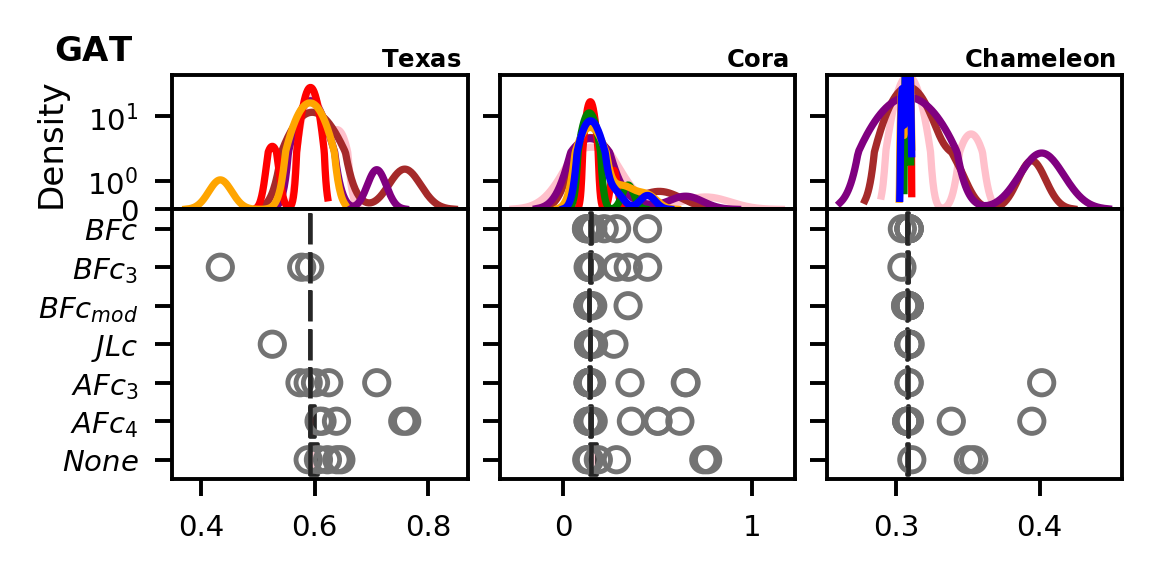

In [30]:
figTotal, axTotal = plt.subplot_mosaic([['Dens_Texas','Dens_Texas','Dens_Texas','.','Dens_Cora','Dens_Cora','Dens_Cora','.','Dens_Chameleon','Dens_Chameleon','Dens_Chameleon'],
                                        ['BP_Texas','BP_Texas','BP_Texas','.','BP_Cora','BP_Cora','BP_Cora','.','BP_Chameleon','BP_Chameleon','BP_Chameleon']],figsize = (3.5,1.5),dpi = 350,
                             gridspec_kw = {'width_ratios': [0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5] ,'height_ratios': [0.5,1],'hspace': 0})

right = 0.98
top = 1.2
left = 0.08

axTotal[f'Dens_Texas'].text(-0.4, 1.3,
                        horizontalalignment='left',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_Texas'].transAxes,s = r"$\mathbf{GAT}$",fontsize = 7)


for dataset_name in dataset_names_GAT_GraphSAGE:
    #if dataset_name in ["Texas","Cornell","Wisconsin"]:
    axTotal[f'Dens_{dataset_name}'].text(right, top,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_{dataset_name}'].transAxes,s = r"$\mathbf{"+dataset_name+"}$",fontsize = 5)



    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy_top_GAT[dataset_name],ax = axTotal[f'Dens_{dataset_name}'],palette= palette_colors_curvature,legend=False,common_norm=False,log_scale=(False,True))

    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy_top_GAT[dataset_name],ax = axTotal[f'BP_{dataset_name}'],orient = "y",palette=palette_colors_curvature,legend=False)

    axTotal[f'BP_{dataset_name}'].set_xlabel("",fontsize = 7)
    axTotal[f'Dens_{dataset_name}'].set_xlabel("",fontsize = 7)

    axTotal[f'Dens_{dataset_name}'].set_yscale("symlog")
    axTotal[f'Dens_{dataset_name}'].tick_params(labelsize = 6)
    axTotal[f'BP_{dataset_name}'].tick_params(labelsize = 6)
    

    if dataset_name in ["Texas"]:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("Density",fontsize = 7)
        axTotal[f'Dens_{dataset_name}'].set_ylim(0,65)
        axTotal[f'BP_{dataset_name}'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$",r"$None$"])
    else:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("",fontsize = 7)

    _ = axTotal[f'BP_{dataset_name}'].sharex(axTotal[f'Dens_{dataset_name}'])   
    _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_xticklabels()]
    

    if dataset_name not in ["Texas"]:
        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
        
figTotal.savefig("results_figures/hyperparameter_sweep_total_GAT.pdf",bbox_inches='tight')

## Loading data

In [9]:
dataset_names = ['Texas','Cornell','Wisconsin','Chameleon','Squirrel','Actor','Cora','Citeseer','Pubmed','MUTAG','PROTEINS']
curvature_types = ['BFc_w4cycle','BFc_no4cycle','BFc_mod','JLc','AFc_3','AFc_4','None']

In [87]:
dict_classification_datasets = {}
dict_classification_datasets_meanaccuracy = {}
dict_classification_datasets_meanaccuracy_top = {}

top_x_considered = 100
min_number = 8000
for dataset_name in dataset_names:#["chameleon_filtered"]:
    dictionary_dataset = {}
    dictionary_dataset_meanaccuracy = {}
    dictionary_dataset_meanaccuracy_top = {}
    for curvature_type in curvature_types:
        #dataset = pd.read_csv(f"{path_load}/time_runs/{dataset_name}_{curvature_type}_time.csv",nrows = 1000)
        dataset = pd.read_csv(f"{path_load}/{dataset_name}_{curvature_type}.csv",nrows = 1000)
        dataset = dataset.loc[dataset['weight_decay'] < 0.6].reset_index(drop=True)
        dataset = dataset.loc[dataset['learning_rate'] < 0.5].reset_index(drop=True)
        if len(dataset) < min_number:
            min_number = len(dataset)
        #dataset = dataset.loc[dataset['learning_rate'] < 0.05].reset_index(drop=True)
        dictionary_dataset[curvature_type] = dataset

        mean_accuracy = dataset['mean test accuracy']
        #mean_accuracy = dataset['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy[curvature_type] = mean_accuracy

        mean_accuracy_top = mean_accuracy.sort_values(ascending = False)[:top_x_considered].reset_index(drop=True)
        #mean_accuracy_top = dataset.loc[dataset['E[final_test_accuracy]']> 0.20*1.05]['E[final_test_accuracy]']
        dictionary_dataset_meanaccuracy_top[curvature_type] = mean_accuracy_top

    dict_classification_datasets[dataset_name] = dictionary_dataset
    dict_classification_datasets_meanaccuracy[dataset_name] = dictionary_dataset_meanaccuracy
    dict_classification_datasets_meanaccuracy_top[dataset_name] = dictionary_dataset_meanaccuracy_top
print(f"Minimum number of runs across all datasets and curvature types: {min_number}")

Minimum number of runs across all datasets and curvature types: 675


# Result figures

## Mean and std of top ranks

In [21]:
for dataset_name in dataset_names:#["chameleon_filtered"]:
    mean_accuracy_top = pd.DataFrame(dict_classification_datasets_meanaccuracy_top[dataset_name]) #dictionary_all_mean_accuracy_top[dataset_name]
    print(f"=============={dataset_name}================\n")
    mean_std_top = pd.DataFrame({'mean':np.round(mean_accuracy_top.mean()*100,2),'std':np.round(mean_accuracy_top.std()*100,2)})
    print(mean_std_top.T)
    print("\n")
    print(pd.DataFrame(dict_classification_datasets_meanaccuracy_top[dataset_name]).median())


==============Texas================

      BFc_w4cycle  BFc_no4cycle  BFc_mod    JLc  AFc_3  AFc_4   None
mean        59.26         59.26    59.26  59.26  59.63  59.72  59.95
std          0.00          0.00     0.00   0.00   0.68   0.53   1.12


BFc_w4cycle     0.592593
BFc_no4cycle    0.592593
BFc_mod         0.592593
JLc             0.592593
AFc_3           0.593333
AFc_4           0.595370
None            0.594259
dtype: float64
==============Cornell================

      BFc_w4cycle  BFc_no4cycle  BFc_mod    JLc  AFc_3  AFc_4   None
mean        53.60         53.58    53.71  53.57  54.11  53.64  53.67
std          0.25          0.11     0.52   0.01   1.42   0.10   0.15


BFc_w4cycle     0.535714
BFc_no4cycle    0.535714
BFc_mod         0.535714
JLc             0.535714
AFc_3           0.536429
AFc_4           0.536071
None            0.536071
dtype: float64
==============Wisconsin================

      BFc_w4cycle  BFc_no4cycle  BFc_mod    JLc  AFc_3  AFc_4   None
mean        54.0

## Total hyperparameter sweep


In [55]:
def hyperparameter_density_plot(dataset_name):

    figTotal, axTotal = plt.subplot_mosaic([['Dens','Dens','Dens'],
                                            ['BP','BP','BP']],figsize = (3.14961,3.14961+1.1811),dpi = 200,
                                gridspec_kw = {'width_ratios': [0.5,0.01,0.5] ,'height_ratios': [1,1],'hspace': 0})
    #6 op 8 cm

    right = 0.98
    top = 1.15
    left = 0.0


    #if dataset_name in ["Texas","Cornell","Wisconsin"]:
    axTotal[f'Dens'].text(left, top,
                            horizontalalignment='left',
                            verticalalignment='top',
                            transform=axTotal[f'Dens'].transAxes,s = r"$\mathbf{"+dataset_name+"}$",fontsize = 16)


    flierprops = dict(marker='D',  linewidth = 0.5,edgecolor='black',s = 10)

    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy[dataset_name],ax = axTotal[f'Dens'],
                    palette= palette_colors_curvature,
                    legend=False,common_norm=False,log_scale=(False,True),
                    linewidth = 2.5)
    
    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy[dataset_name],ax = axTotal[f'BP'],
                      orient = "y",palette= palette_colors_curvature,
                      legend=False,
                      flier_kws = flierprops,box_kws = {'linewidth':0.4})
    
    [i.set_linewidth(2) for i in axTotal['Dens'].spines.values()]
    [i.set_linewidth(2) for i in axTotal['BP'].spines.values()]

    axTotal['Dens'].set_xlabel("",fontsize = 12)

    axTotal['Dens'].set_ylabel("Density",fontsize = 16)
    axTotal['BP'].set_xlabel("Accuracy",fontsize = 16)
    #labels = [r"$" + curvature + "$" for curvature in curvature_types]
    #axTotal['BP'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$","None"])
    axTotal['BP'].set_yticks([0,1],[r"$BFc_3$",r"$None$"])
    axTotal['Dens'].set_yscale("symlog")
    
    axTotal['Dens'].tick_params(labelsize = 12)
    axTotal['BP'].tick_params(labelsize = 12)
    

    _ = axTotal['BP'].sharex(axTotal['Dens'])   
    _ = [label.set_visible(False) for label in axTotal['Dens'].get_xticklabels()]
    
    figTotal.savefig(f"results_figures/{dataset_name}_hyperparameterplot.pdf",dpi = 1000,bbox_inches = "tight")            


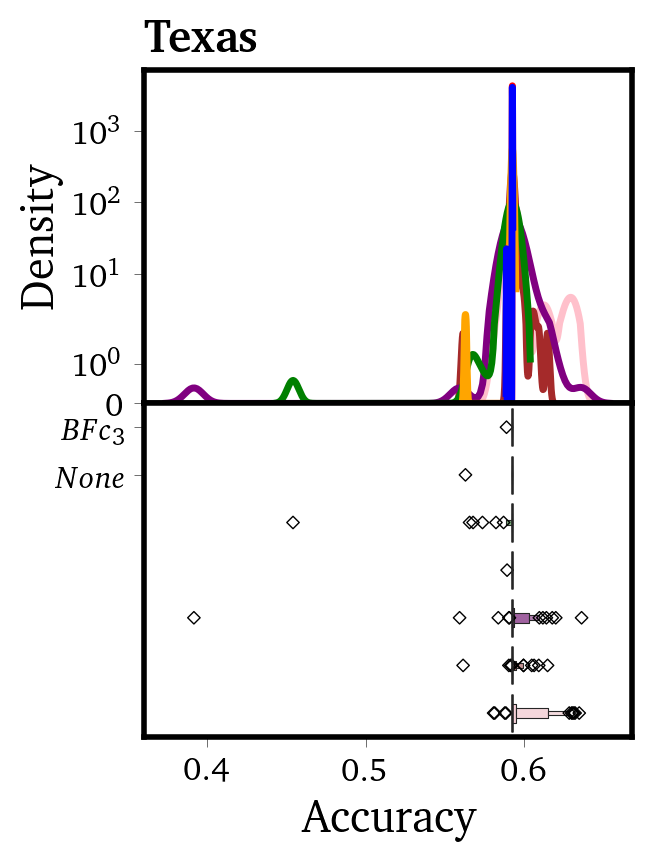

In [56]:
hyperparameter_density_plot("Texas")

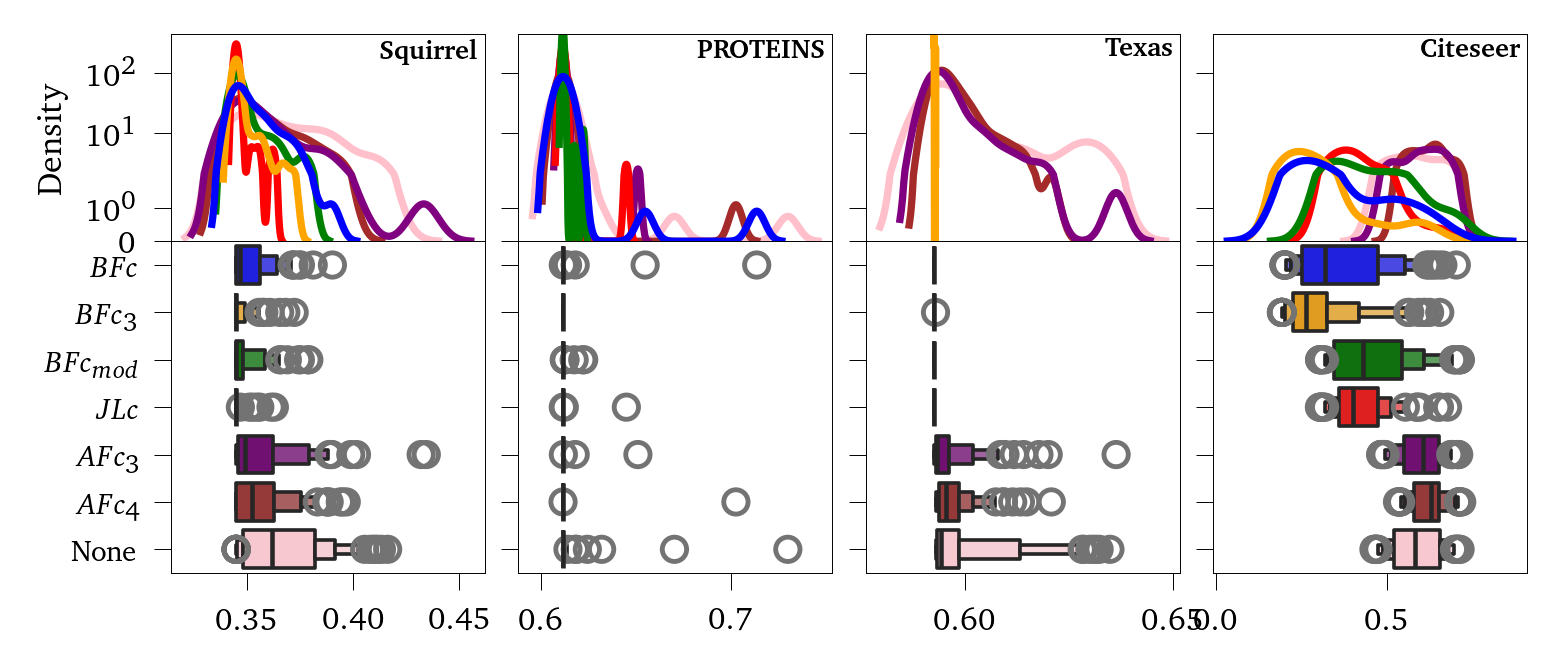

In [26]:
figTotal, axTotal = plt.subplot_mosaic([['Dens_Squirrel','Dens_Squirrel','Dens_Squirrel','.','Dens_PROTEINS','Dens_PROTEINS','Dens_PROTEINS','.','Dens_Texas','Dens_Texas','Dens_Texas','.','Dens_Citeseer','Dens_Citeseer','Dens_Citeseer'],
                                        ['BP_Squirrel','BP_Squirrel','BP_Squirrel','.','BP_PROTEINS','BP_PROTEINS','BP_PROTEINS','.','BP_Texas','BP_Texas','BP_Texas','.','BP_Citeseer','BP_Citeseer','BP_Citeseer']],figsize = (5,2),dpi = 350,
                             gridspec_kw = {'width_ratios': [0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5] ,'height_ratios': [0.5,0.8],'hspace': 0})

right = 0.98
top = 0.98
left = 0.08

for dataset_name in ["Squirrel","PROTEINS","Texas","Citeseer"]:#dataset_names:
    #if dataset_name in ["Texas","Cornell","Wisconsin"]:
    axTotal[f'Dens_{dataset_name}'].text(right, top,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_{dataset_name}'].transAxes,s = r"$\mathbf{"+dataset_name+"}$",fontsize = 5)



    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy_top[dataset_name],ax = axTotal[f'Dens_{dataset_name}'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},legend=False,common_norm=False,log_scale=(False,True))

    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy_top[dataset_name],ax = axTotal[f'BP_{dataset_name}'],orient = "y",palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},legend=False)

    axTotal[f'BP_{dataset_name}'].set_xlabel("",fontsize = 7)
    axTotal[f'Dens_{dataset_name}'].set_xlabel("",fontsize = 7)
    if dataset_name in ["Squirrel"]:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("Density",fontsize = 7)
        axTotal[f'BP_{dataset_name}'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$","None"])
    else:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("",fontsize = 7)
    axTotal[f'Dens_{dataset_name}'].set_yscale("symlog")
    axTotal[f'Dens_{dataset_name}'].tick_params(labelsize = 6)
    axTotal[f'BP_{dataset_name}'].tick_params(labelsize = 6)
    
    _ = axTotal[f'BP_{dataset_name}'].sharex(axTotal[f'Dens_{dataset_name}'])   
    _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_xticklabels()]

    if dataset_name not in ["Squirrel"]:
        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_Squirrel'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_Squirrel'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
        


figTotal.savefig("results_figures/hyperparameter_sweep_total_Poster.pdf",bbox_inches='tight')

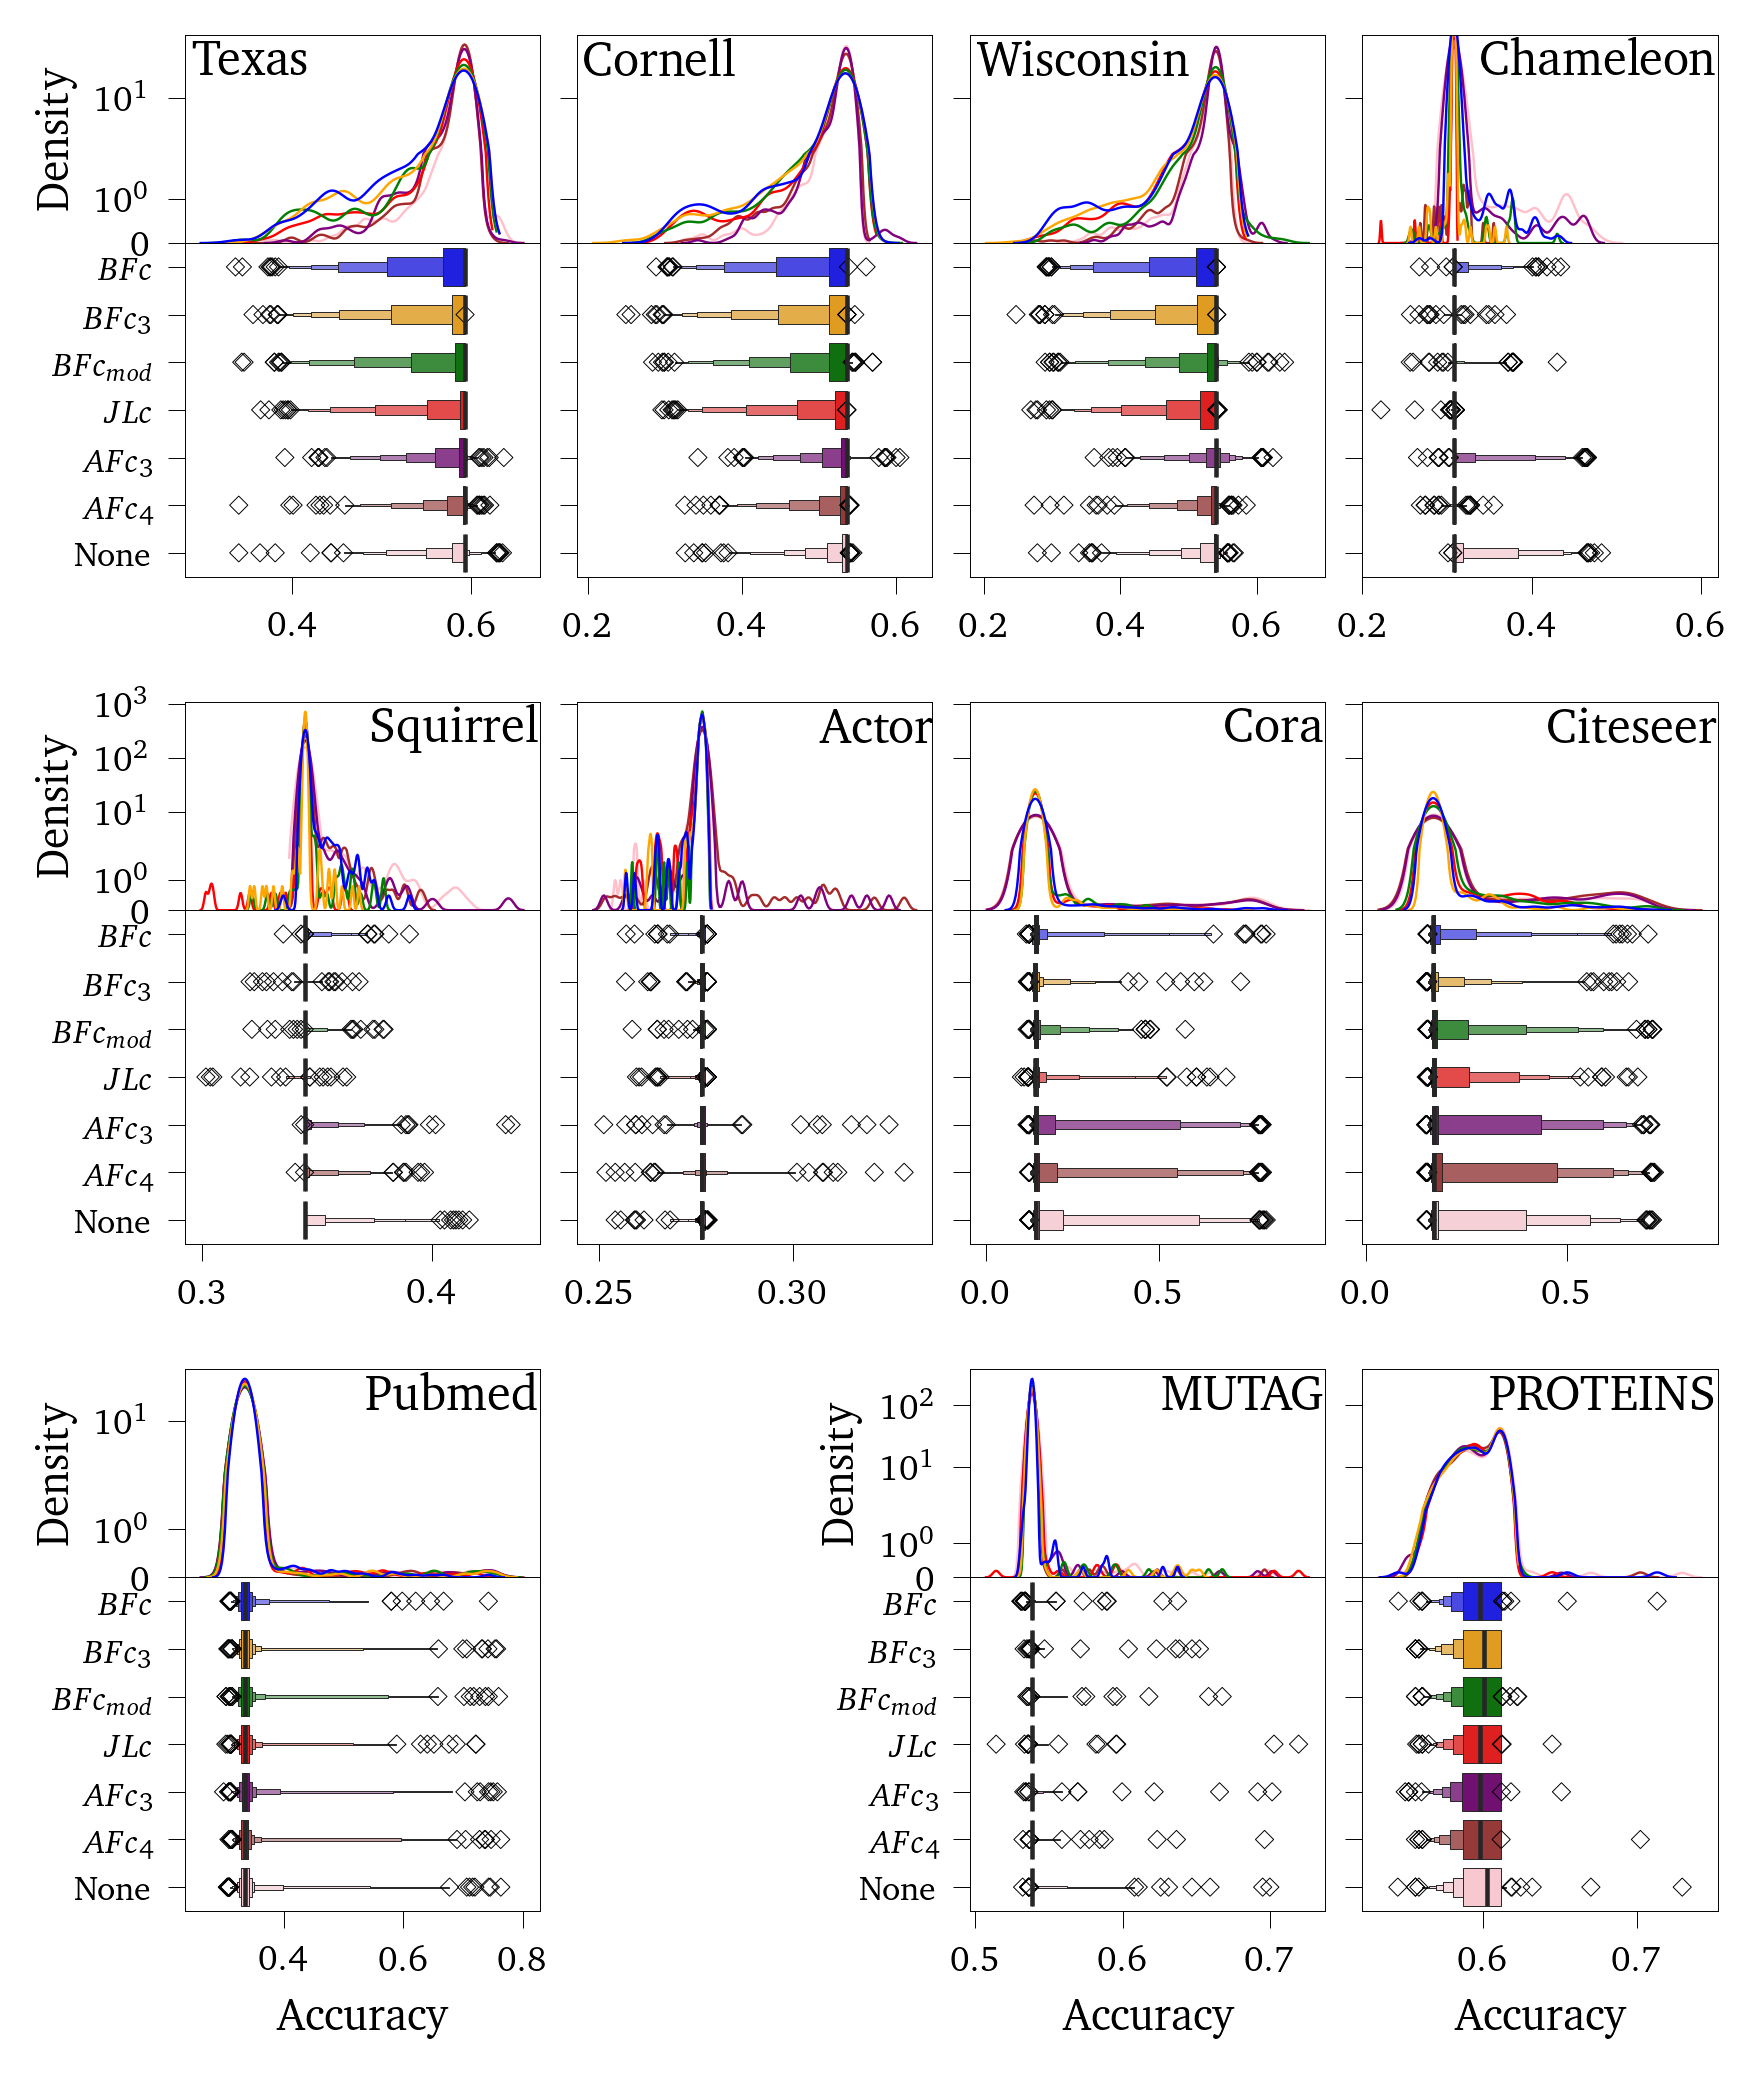

In [85]:
figTotal, axTotal = plt.subplot_mosaic([['Dens_Texas','Dens_Texas','Dens_Texas','.','Dens_Cornell','Dens_Cornell','Dens_Cornell','.','Dens_Wisconsin','Dens_Wisconsin','Dens_Wisconsin','.','Dens_Chameleon','Dens_Chameleon','Dens_Chameleon'],
                                        ['BP_Texas','BP_Texas','BP_Texas','.','BP_Cornell','BP_Cornell','BP_Cornell','.','BP_Wisconsin','BP_Wisconsin','BP_Wisconsin','.','BP_Chameleon','BP_Chameleon','BP_Chameleon'],
                                        ['.','.','.','.','.','.','.','.','.','.','.','.','.','.','.'],
                                        ['Dens_Squirrel','Dens_Squirrel','Dens_Squirrel','.','Dens_Actor','Dens_Actor','Dens_Actor','.','Dens_Cora','Dens_Cora','Dens_Cora','.','Dens_Citeseer','Dens_Citeseer','Dens_Citeseer'],
                                        ['BP_Squirrel','BP_Squirrel','BP_Squirrel','.','BP_Actor','BP_Actor','BP_Actor','.','BP_Cora','BP_Cora','BP_Cora','.','BP_Citeseer','BP_Citeseer','BP_Citeseer'],
                                        ['.','.','.','.','.','.','.','.','.','.','.','.','.','.','.'],
                                        ['Dens_Pubmed','Dens_Pubmed','Dens_Pubmed','.','.','.','.','.','Dens_MUTAG','Dens_MUTAG','Dens_MUTAG','.','Dens_PROTEINS','Dens_PROTEINS','Dens_PROTEINS'],
                                        ['BP_Pubmed','BP_Pubmed','BP_Pubmed','.','.','.','.','.','BP_MUTAG','BP_MUTAG','BP_MUTAG','.','BP_PROTEINS','BP_PROTEINS','BP_PROTEINS']
                                        ],figsize = (full_width, full_height*0.9),dpi = 350,
                             gridspec_kw = {'width_ratios': [0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5,0.01,0.5] ,'height_ratios': [0.5,0.8,0.3,0.5,0.8,0.3,0.5,0.8],'hspace': 0})

right = 1.00
top = 0.98
left = 0.02

for dataset_name in ["Texas","Cornell","Wisconsin","Chameleon","Squirrel","Actor","Cora","Citeseer","Pubmed","MUTAG","PROTEINS"]:#dataset_names:
    if dataset_name in ["Texas","Cornell","Wisconsin"]:
        axTotal[f'Dens_{dataset_name}'].text(left, top,
                        horizontalalignment='left',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_{dataset_name}'].transAxes,s = f"{dataset_name}",fontsize = 10)
    else:
        axTotal[f'Dens_{dataset_name}'].text(right, top,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTotal[f'Dens_{dataset_name}'].transAxes,s =  f"{dataset_name}",fontsize = 10)

    flierprops = dict(marker='D',  linewidth = 0.2,edgecolor='black',s = 7)

    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy[dataset_name],ax = axTotal[f'Dens_{dataset_name}'],linewidth = 0.5,
                    palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},
                    legend=False,common_norm=False,log_scale=(False,True))

    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy[dataset_name],ax = axTotal[f'BP_{dataset_name}'],orient = "y",
                      palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},
                       flier_kws = flierprops,box_kws = {'linewidth':0.2},
                      legend=False)

    axTotal[f'BP_{dataset_name}'].set_xlabel("")
    axTotal[f'Dens_{dataset_name}'].set_xlabel("")
    if dataset_name in ["Texas","Squirrel","Pubmed","MUTAG"]:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("Density")
        axTotal[f'BP_{dataset_name}'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$","None"])
    else:
        axTotal[f'Dens_{dataset_name}'].set_ylabel("")
    axTotal[f'Dens_{dataset_name}'].set_yscale("symlog")
    axTotal[f'Dens_{dataset_name}'].tick_params()
    axTotal[f'BP_{dataset_name}'].tick_params()
    
    _ = axTotal[f'BP_{dataset_name}'].sharex(axTotal[f'Dens_{dataset_name}'])   
    _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_xticklabels()]
    
    if dataset_name in ["Cornell","Wisconsin","Chameleon"]:


        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_Texas'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
    
    elif dataset_name in ["Actor","Cora","Citeseer"]:
        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_Squirrel'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_Squirrel'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
    elif dataset_name ==  "PROTEINS":
        _ = axTotal[f'Dens_{dataset_name}'].sharey(axTotal['Dens_MUTAG'])   
        _ = [label.set_visible(False) for label in axTotal[f'Dens_{dataset_name}'].get_yticklabels()]

        _ = axTotal[f'BP_{dataset_name}'].sharey(axTotal['BP_MUTAG'])   
        _ = [label.set_visible(False) for label in axTotal[f'BP_{dataset_name}'].get_yticklabels()]
    if dataset_name in ["Pubmed","PROTEINS","MUTAG"]:
        axTotal[f'BP_{dataset_name}'].set_xlabel("Accuracy")
    if dataset_name == "Chameleon":
        axTotal[f'Dens_{dataset_name}'].set_xlim(0.20,0.62)
figTotal.subplots_adjust(left=0.1, right=0.99, bottom=0.10, top=0.95)
figTotal.savefig("results_figures/hyperparameter_sweep_total_ICLR.pdf")

## Trial with expected value

In [190]:
dict_classification_datasets = {}

for dataset_name in ['Actor']:
    dictionary_dataset = {}
    dictionary_dataset_meanaccuracy = {}
    dictionary_dataset_meanaccuracy_top = {}
    for curvature_type in curvature_types:
        dataset = pd.read_csv(f"{path_load}time_runs/{dataset_name}_{curvature_type}_time.csv",nrows = 1000)
        dictionary_dataset[curvature_type] = dataset


    dict_classification_datasets[dataset_name] = dictionary_dataset


In [18]:
def _cdf_with_replacement(i,n,N):
    return (i/N)**n

def _cdf_without_replacement(i,n,N):
    return scipy.special.comb(i,n) / scipy.special.comb(N,n)

def _compute_variance(N, cur_data, expected_max_cond_n, pdfs):
    """
    this computes the standard error of the max.
    this is what the std dev of the bootstrap estimates of the mean of the max converges to, as
    is stated in the last sentence of the summary on page 10 of http://www.stat.cmu.edu/~larry/=stat705/Lecture13.pdf
    uses equation 
    """
    variance_of_max_cond_n = []
    for n in range(N):
        # for a given n, estimate variance with \sum(p(x) * (x-mu)^2), where mu is \sum(p(x) * x).
        cur_var = 0
        for i in range(N):
            cur_var += (cur_data[i] - expected_max_cond_n[n])**2 * pdfs[n][i]
        cur_var = np.sqrt(cur_var)
        variance_of_max_cond_n.append(cur_var)
    return variance_of_max_cond_n
    

# this implementation assumes sampling with replacement for computing the empirical cdf
def samplemax(df, with_replacement=True):

    validation_performance = df['mean test accuracy']
    time = df['Runtime']

    validation_performance = list(validation_performance)
    time = list(time)
    validation_performance.sort()
    N = len(validation_performance)
    pdfs = []
    for n in range(1,N+1):
        # the CDF of the max
        F_Y_of_y = []
        for i in range(1,N+1):
            if with_replacement:
                F_Y_of_y.append(_cdf_with_replacement(i,n,N))
            else:
                F_Y_of_y.append(_cdf_without_replacement(i,n,N))

        f_Y_of_y = []
        cur_cdf_val = 0
        for i in range(len(F_Y_of_y)):
            f_Y_of_y.append(F_Y_of_y[i] - cur_cdf_val)
            cur_cdf_val = F_Y_of_y[i]
        
        pdfs.append(f_Y_of_y)

    expected_max_cond_n = []
    time_ran = []
    for n in range(N):
        # for a given n, estimate expected value with \sum(x * p(x)), where p(x) is prob x is max.
        cur_expected = 0
        for i in range(N):
            cur_expected += validation_performance[i] * pdfs[n][i]
        if n == 0:
            time_ran.append(time[0])
        else:
            time_ran.append(time_ran[n-1] + time[n])
        
        expected_max_cond_n.append(cur_expected)

    var_of_max_cond_n = _compute_variance(N, validation_performance, expected_max_cond_n, pdfs)

    return {"mean":expected_max_cond_n, "var":var_of_max_cond_n, "max": np.max(validation_performance),'min':np.min(validation_performance),'time':time_ran}

Text(0.1, 0.9, 'Actor')

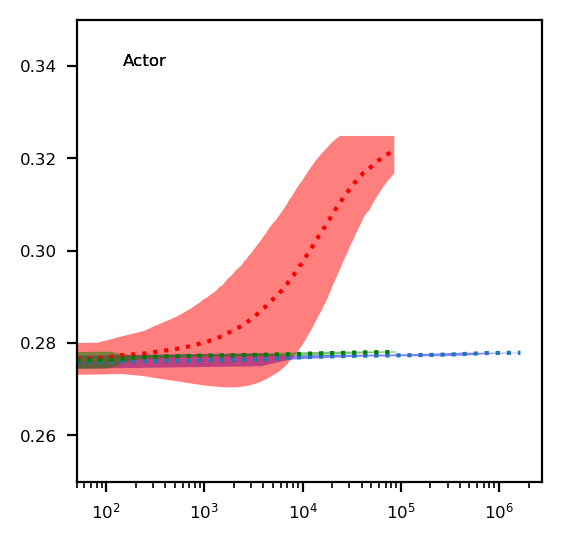

In [226]:
fix,ax = plt.subplots(1,1,figsize=(3,3),dpi = 200)

dict_mean_var_max = samplemax(dict_classification_datasets[dataset_name]["BFc_w4cycle"][:1000], with_replacement=True)
dict_mean_var_max_2 = samplemax(dict_classification_datasets[dataset_name]["AFc_3"][:1000], with_replacement=True)
dict_mean_var_max_3 = samplemax(dict_classification_datasets[dataset_name]["None"][:1000], with_replacement=True)


means = [0] + dict_mean_var_max["mean"]
vars = [0] + dict_mean_var_max["var"]
max_acc = dict_mean_var_max['max']
x_axis_1 = [0] + dict_mean_var_max['time']

    
means_2 = [0] + dict_mean_var_max_2["mean"]
vars_2 = [0] + dict_mean_var_max_2["var"]
max_acc_2 = dict_mean_var_max_2['max']
x_axis_2 = [0] + dict_mean_var_max_2['time']

means_3 = [0] + dict_mean_var_max_3["mean"]
vars_3 = [0] + dict_mean_var_max_3["var"]
max_acc_3 = dict_mean_var_max_3['max']
x_axis_3 = [0] + dict_mean_var_max_3['time']


#x_axis = [i+1 for i in range(len(means))]

ax.set_xscale("log")
ax.set_ylim(0.25,0.35)

ax.plot(x_axis_1,means,':',label = "Mean")

minus_vars = np.array(means)-np.array(vars)
plus_vars = [x + y if (x + y) <= max_acc else max_acc for x,y in zip(means, vars)]
ax.fill_between(x_axis_1,
                        minus_vars,
                        plus_vars,
                        alpha=0.5,
                        facecolor='blue')


ax.plot(x_axis_2,means_2,':',label = "Mean",color = 'red')

minus_vars_2 = np.array(means_2)-np.array(vars_2)
plus_vars_2 = [x + y if (x + y) <= max_acc_2 else max_acc_2 for x,y in zip(means_2, vars_2)]
ax.fill_between(x_axis_2,
                        minus_vars_2,
                        plus_vars_2,
                        alpha=0.5,
                        facecolor='red')
    
ax.tick_params(labelsize = 6)
ax.text(0.1,0.9,dataset_name,transform = ax.transAxes,fontsize = 6)

ax.plot(x_axis_3,means_3,':',label = "Mean",color = 'green')

minus_vars_3 = np.array(means_3)-np.array(vars_3)
plus_vars_3 = [x + y if (x + y) <= max_acc_3 else max_acc_3 for x,y in zip(means_3, vars_3)]
ax.fill_between(x_axis_3,
                        minus_vars_3,
                        plus_vars_3,
                        alpha=0.5,
                        facecolor='green')
    
ax.tick_params(labelsize = 6)
ax.text(0.1,0.9,dataset_name,transform = ax.transAxes,fontsize = 6)


In [51]:
dict_classification_datasets['Wisconsin']['AFc_3'][~dict_classification_datasets['Wisconsin']['AFc_3']['mean test accuracy'].isna()]

,Name,Agent,State,Notes,User,Tags,Created,Runtime,Sweep,C+,...,parameters.tau.distribution,parameters.tau.max,parameters.tau.min,parameters.weight_decay.distribution,parameters.weight_decay.max,parameters.weight_decay.min,tau,weight_decay,mean accuracy,mean test accuracy
0,eager-sweep-1583,NaN,finished,-,NaN,NaN,2024-05-19T01:40:33.000Z,150,w1tslq43,1.076141,...,NaN,NaN,NaN,NaN,NaN,NaN,46,0.092470,0.502973,0.543514
1,mild-sweep-1582,NaN,finished,-,NaN,NaN,2024-05-19T01:38:23.000Z,123,w1tslq43,18.690064,...,NaN,NaN,NaN,NaN,NaN,NaN,300,0.518671,0.502973,0.540541
2,eager-sweep-1581,NaN,finished,-,NaN,NaN,2024-05-19T01:35:48.000Z,153,w1tslq43,17.002505,...,NaN,NaN,NaN,NaN,NaN,NaN,253,0.151681,0.502973,0.541081
3,fanciful-sweep-1580,NaN,finished,-,NaN,NaN,2024-05-19T01:34:09.000Z,93,w1tslq43,3.492242,...,NaN,NaN,NaN,NaN,NaN,NaN,246,0.516887,0.503243,0.540541
4,fancy-sweep-1579,NaN,finished,-,NaN,NaN,2024-05-19T01:30:57.000Z,186,w1tslq43,14.282496,...,NaN,NaN,NaN,NaN,NaN,NaN,265,0.159630,0.495946,0.535676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,vibrant-sweep-587,NaN,finished,-,NaN,NaN,2024-05-15T01:38:56.000Z,65,w1tslq43,7.867101,...,NaN,NaN,NaN,NaN,NaN,NaN,384,0.315337,0.504595,0.543514
996,legendary-sweep-586,NaN,finished,-,NaN,NaN,2024-05-15T01:37:48.000Z,65,w1tslq43,13.041118,...,NaN,NaN,NaN,NaN,NaN,NaN,304,0.516503,0.540811,0.563243
997,clean-sweep-585,NaN,finished,-,NaN,NaN,2024-05-15T01:36:00.000Z,104,w1tslq43,6.282350,...,NaN,NaN,NaN,NaN,NaN,NaN,76,0.510500,0.487838,0.525405
998,different-sweep-584,NaN,finished,-,NaN,NaN,2024-05-15T01:33:50.000Z,128,w1tslq43,10.458525,...,NaN,NaN,NaN,NaN,NaN,NaN,208,0.454587,0.486486,0.534054


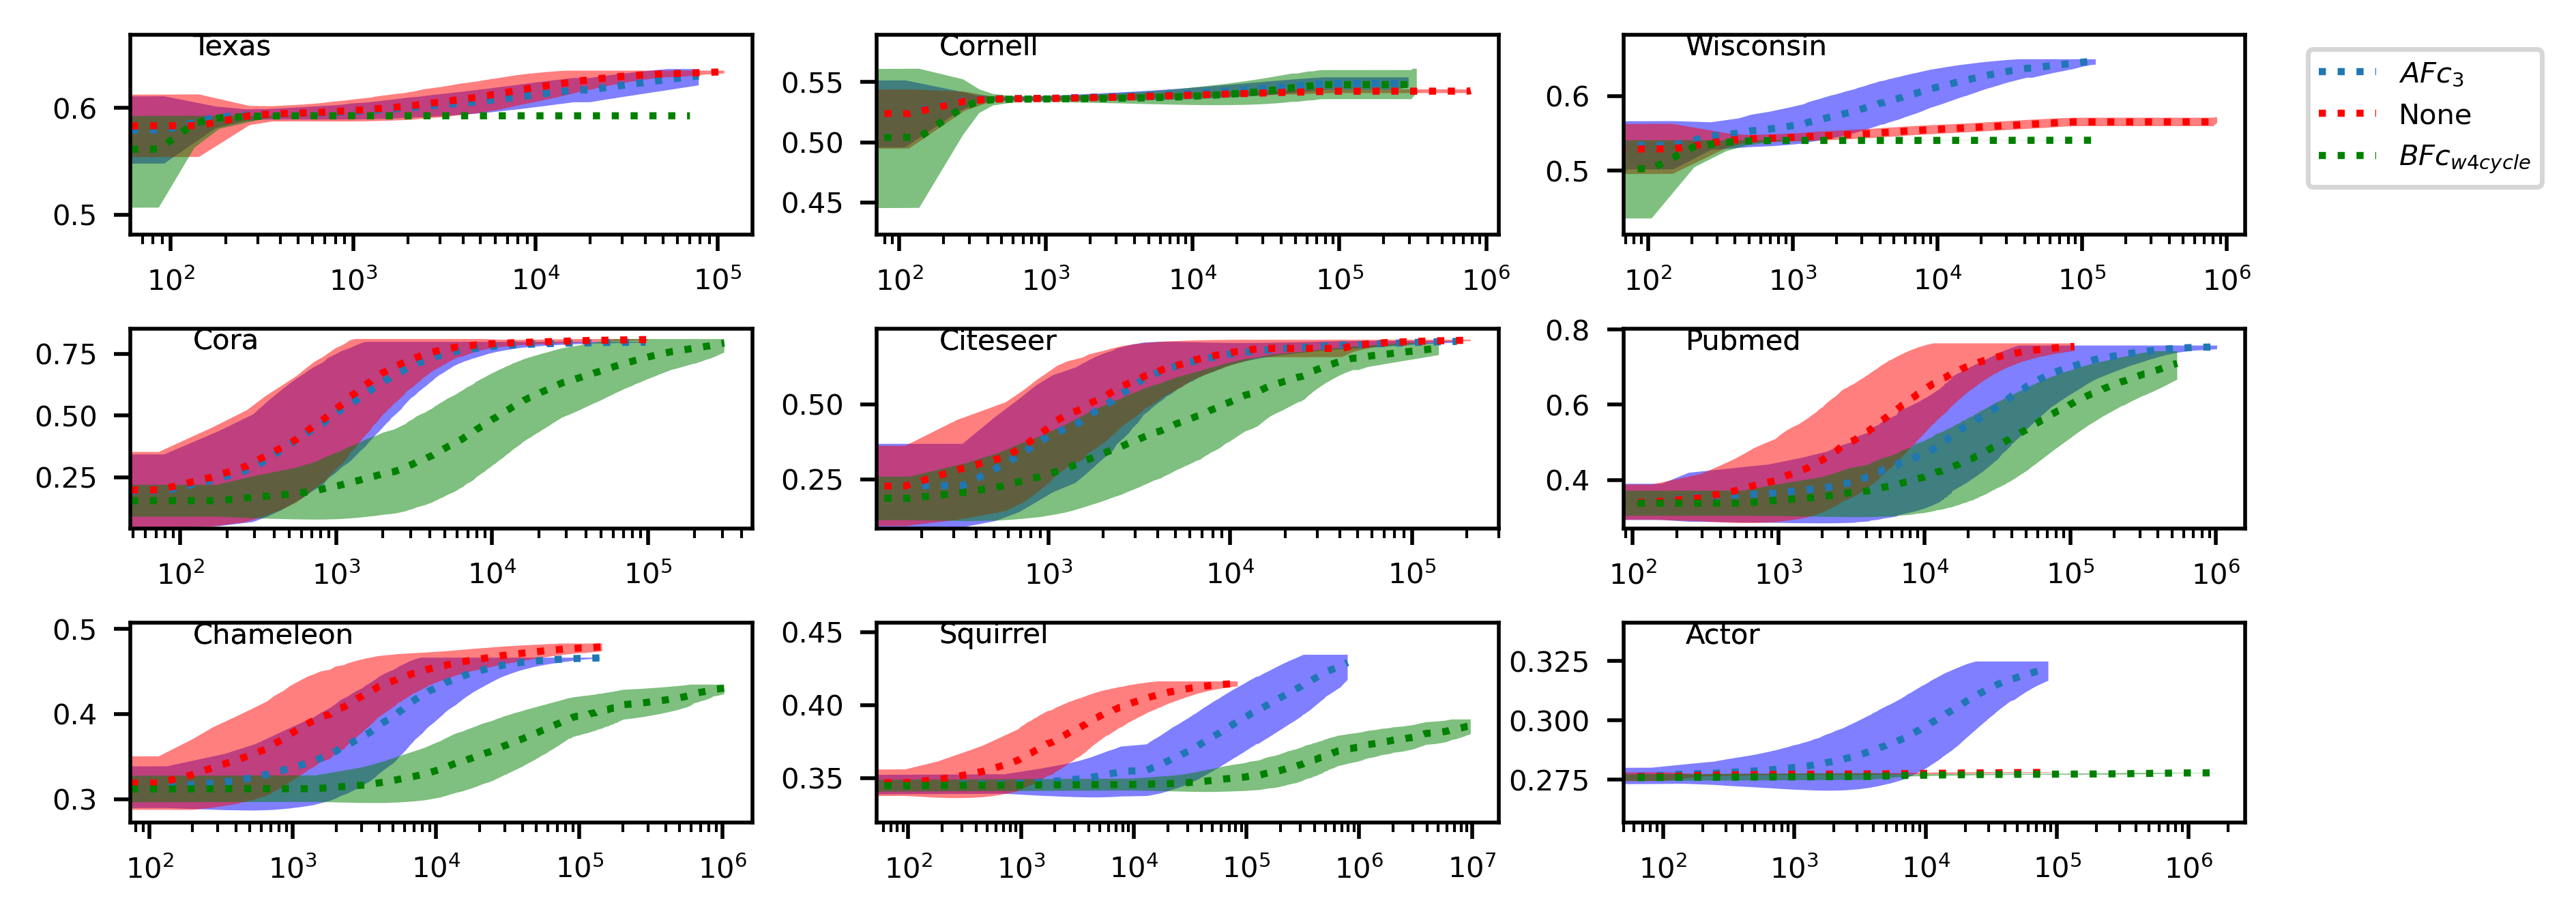

In [63]:
fig, ax = plt.subplot_mosaic([['Texas','Cornell','Wisconsin'],
                              ['.','.','.'],
                              ["Cora","Citeseer","Pubmed"],
                              ['.','.','.'],
                              ['Chameleon','Squirrel','Actor']
                                      ],figsize = (8,3),dpi = 500,
                             gridspec_kw = {'height_ratios': [1,0.2,1,0.2,1] ,'width_ratios': [1,1,1]})


for idx,dataset_name in enumerate(["Texas","Cornell","Wisconsin","Cora","Citeseer","Pubmed","Chameleon","Squirrel","Actor"]):

    dict_mean_var_max = samplemax(dict_classification_datasets[dataset_name]["AFc_3"][:1000][~dict_classification_datasets[dataset_name]['AFc_3']['mean test accuracy'][:1000].isna()], with_replacement=True)
    dict_mean_var_max_2 = samplemax(dict_classification_datasets[dataset_name]["None"][:1000][~dict_classification_datasets[dataset_name]['None']['mean test accuracy'][:1000].isna()], with_replacement=True)
    dict_mean_var_max_3 = samplemax(dict_classification_datasets[dataset_name]["BFc_w4cycle"][:1000][~dict_classification_datasets[dataset_name]['BFc_w4cycle']['mean test accuracy'][:1000].isna()], with_replacement=True)


    means = [0] + dict_mean_var_max["mean"]
    vars = [0] + dict_mean_var_max["var"]
    max_acc = dict_mean_var_max['max']
    x_axis_1 = [0] + dict_mean_var_max['time']
    

        
    means_2 = [0] + dict_mean_var_max_2["mean"]
    vars_2 = [0] + dict_mean_var_max_2["var"]
    max_acc_2 = dict_mean_var_max_2['max']
    x_axis_2 = [0] + dict_mean_var_max_2['time']

    means_3 = [0] + dict_mean_var_max_3["mean"]
    vars_3 = [0] + dict_mean_var_max_3["var"]
    max_acc_3 = dict_mean_var_max_3['max']
    x_axis_3 = [0] + dict_mean_var_max_3['time']

    x_axis = [i+1 for i in range(len(means))]

    ax[dataset_name].set_xscale("log")


    ax[dataset_name].plot(x_axis_1,means,':',label = r"$AFc_3$")

    minus_vars = np.array(means)-np.array(vars)
    plus_vars = [x + y if (x + y) <= max_acc else max_acc for x,y in zip(means, vars)]
    ax[dataset_name].fill_between(x_axis_1,
                        minus_vars,
                        plus_vars,
                        alpha=0.5,
                        facecolor='blue')


    ax[dataset_name].plot(x_axis_2,means_2,':',label = "None",color = 'red')

    minus_vars_2 = np.array(means_2)-np.array(vars_2)
    plus_vars_2 = [x + y if (x + y) <= max_acc_2 else max_acc_2 for x,y in zip(means_2, vars_2)]
    ax[dataset_name].fill_between(x_axis_2,
                        minus_vars_2,
                        plus_vars_2,
                        alpha=0.5,
                        facecolor='red')
    
    ax[dataset_name].tick_params(labelsize = 6)
    ax[dataset_name].text(0.1,0.9,dataset_name,transform = ax[dataset_name].transAxes,fontsize = 6)

    ax[dataset_name].plot(x_axis_3,means_3,':',label = r"$BFc_{w4cycle}$",color = 'green')

    minus_vars_3 = np.array(means_3)-np.array(vars_3)
    plus_vars_3 = [x + y if (x + y) <= max_acc_3 else max_acc_3 for x,y in zip(means_3, vars_3)]
    ax[dataset_name].fill_between(x_axis_3,
                        minus_vars_3,
                        plus_vars_3,
                        alpha=0.5,
                        facecolor='green')
    
    ax[dataset_name].tick_params(labelsize = 6)
    ax[dataset_name].text(0.1,0.9,dataset_name,transform = ax[dataset_name].transAxes,fontsize = 6)

    if dataset_name == "Wisconsin":
        ax[dataset_name].legend(loc = "upper right",bbox_to_anchor = (1.5,1) ,fontsize = 6)

    
    
    min_tot = np.nanmin([np.nanmin(minus_vars[1:]),np.nanmin(minus_vars_2[1:]),np.nanmin(minus_vars_3[1:])])
    max_tot = np.nanmax([np.nanmax(plus_vars[1:]),np.nanmax(plus_vars_2[1:]),np.nanmax(plus_vars_3[1:])])
    ax[dataset_name].set_ylim(min_tot - min_tot/20,max_tot + max_tot/20)


## Temporal evolution of distribution

### Functions 

In [130]:
def draw_distribution_analysis_single(dataset_name):
    figTemporal,axTemporal =plt.subplot_mosaic([[f'{dataset_name}1','.',f'{dataset_name}2','.',f'{dataset_name}3'],
                                        ['.','.','.','.','.',],
                                        [f'{dataset_name}_dist',f'{dataset_name}_dist',f'{dataset_name}_dist',f'{dataset_name}_dist',f'{dataset_name}_dist'],
                                        [f'{dataset_name}_mean',f'{dataset_name}_mean',f'{dataset_name}_mean',f'{dataset_name}_mean',f'{dataset_name}_mean'],
                                        [f'{dataset_name}_std',f'{dataset_name}_std',f'{dataset_name}_std',f'{dataset_name}_std',f'{dataset_name}_std']],
 
                                        figsize = (2.,3),dpi = 300,
                                        gridspec_kw = {'width_ratios': [1,0.05,1,0.05,1] ,'height_ratios': [0.8,0.45,0.7,0.7,0.7],'hspace': 0})


    length = len(pd.DataFrame(dict_classification_datasets_meanaccuracy[dataset_name]))
    data = pd.DataFrame(dict_classification_datasets_meanaccuracy[dataset_name])
    _ = sns.kdeplot(data = data[:int(0.33*length)],ax = axTemporal[dataset_name+'1'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
    _ = sns.kdeplot(data = data[:int(0.66*length)],ax = axTemporal[dataset_name+'2'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
    _ = sns.kdeplot(data = data,ax = axTemporal[dataset_name+'3'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
    axTemporal[dataset_name+f'2'].set_xlabel("Mean Test Accuracy",fontsize = 7)

    letters = ['a','b','c','d']
    for k in range (1,4):
        axTemporal[dataset_name+f'{k}'].set_yscale("symlog")

        axTemporal[dataset_name+f'{k}'].get_legend().remove()  


        axTemporal[dataset_name+f'{k}'].tick_params(labelsize = 6)  


        axTemporal[dataset_name+f'{k}'].text(0.01, 0.97,
                        horizontalalignment='left',
                        verticalalignment='top',
                        transform=axTemporal[dataset_name+f'{k}'].transAxes,s = r"$\mathbf{"+letters[k-1]+".}$",fontsize = 6)

    axTemporal[dataset_name+'2'].sharey(axTemporal[dataset_name+'1'])
    axTemporal[dataset_name+'3'].sharey(axTemporal[dataset_name+'1'])   

    axTemporal[dataset_name+'2'].set_ylabel("")
    axTemporal[dataset_name+'3'].set_ylabel("")

    _ = [label.set_visible(False) for label in axTemporal[dataset_name+'2'].get_yticklabels()]
    _ = [label.set_visible(False) for label in axTemporal[dataset_name+'3'].get_yticklabels()]

    axTemporal[dataset_name+'1'].text(-0.65, 1.35,
                        horizontalalignment='left',
                        verticalalignment='top',
                        transform=axTemporal[dataset_name+'1'].transAxes,s = r"$\mathbf{" + dataset_name + "}$",fontsize = 8)

    axTemporal[dataset_name+'1'].set_ylabel("Density",fontsize = 7)
      

    axTemporal[dataset_name+'1'].text(0.98, 0.95,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTemporal[dataset_name+'1'].transAxes,s = r"$(33\%)$",fontsize = 6)
    axTemporal[dataset_name+'2'].text(0.98, 0.95,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTemporal[dataset_name+'2'].transAxes,s = r"$(66\%)$",fontsize = 6)
    axTemporal[dataset_name+'3'].text(0.98, 0.95,
                        horizontalalignment='right',
                        verticalalignment='top',
                        transform=axTemporal[dataset_name+'3'].transAxes,s = r"$(100\%)$",fontsize = 6)

    for curvaturetype in ['BFc_w4cycle','BFc_no4cycle','BFc_mod','JLc','AFc_3','AFc_4','None']:
            distances = []
            means = []
            measures = []
            stds = []
            maxiter = 100
            epsilon = 0.0001
            for k in range(1,maxiter):
                distance = stats.wasserstein_distance(data[:int((k-1/maxiter)*length)][curvaturetype],data[curvaturetype][:int((k/maxiter)*length)])
                mean = np.mean(data[:int((k/maxiter)*length)][curvaturetype])
                std = np.std(data[:int((k/maxiter)*length)][curvaturetype])
                measure = std**2/(len(data[:int((k/maxiter)*length)][curvaturetype])*epsilon)
                
                means.append(mean)
                stds.append(std)
                measures.append(measure)
                distances.append(distance)
    
            #axTemporal[datasetname+'_dist'].plot(np.array([*range(1,maxiter)])*100/maxiter,distances,'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            color_curvature = palette_colors_curvature[curvaturetype]
            _ = sns.lineplot(data = distances,ax = axTemporal[dataset_name+'_dist'],color = color_curvature)
            axTemporal[dataset_name+'_dist'].tick_params(labelsize = 6)  
            
            axTemporal[dataset_name+'_dist'].set_yscale("log")
            

            axTemporal[dataset_name+'_dist'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[dataset_name+'_dist'].transAxes,s = r"$\mathbf{e.}$",fontsize = 6)
            
            #axTemporal[datasetname+'_mean'].plot(np.array([*range(1,maxiter)])*100/maxiter,np.array(means),'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            _ = sns.lineplot(data = np.array(means),ax = axTemporal[dataset_name+'_mean'],color = color_curvature)
            axTemporal[dataset_name+'_mean'].tick_params(labelsize = 6) 
            
            axTemporal[dataset_name+'_mean'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[dataset_name+'_mean'].transAxes,s = r"$\mathbf{f.}$",fontsize = 6)
            

            #axTemporal[datasetname+'_std'].plot(np.array([*range(1,maxiter)])*100/maxiter,np.array(stds),'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            _ = sns.lineplot(data = np.array(stds),ax = axTemporal[dataset_name+'_std'],color = color_curvature)
            axTemporal[dataset_name+'_std'].tick_params(labelsize = 6) 
            
            axTemporal[dataset_name+'_std'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[dataset_name+'_std'].transAxes,s = r"$\mathbf{g.}$",fontsize = 6)
            

            axTemporal[dataset_name+'_mean'].sharex(axTemporal[dataset_name+'_std'])
            axTemporal[dataset_name+'_std'].sharex(axTemporal[dataset_name+'_std'])
            [label.set_visible(False) for label in axTemporal[dataset_name+'_mean'].get_xticklabels()]        
            [label.set_visible(False) for label in axTemporal[dataset_name+'_dist'].get_xticklabels()]


            axTemporal[dataset_name+'_mean'].set_ylabel(r"$\mu_{x}$",fontsize = 6)
            axTemporal[dataset_name+'_dist'].set_ylabel(r"$W_1(x,(x+1))$",fontsize = 6)
            axTemporal[dataset_name+'_std'].set_ylabel(r"$\sigma_x$",fontsize = 6)

            axTemporal[dataset_name+'_std'].set_xlabel(r"$\%$ of Iterations included ($x$)",fontsize = 7)

    figTemporal.savefig(f"results_figures/distribution_evolution_{dataset_name}.pdf",bbox_inches = 'tight')


In [131]:
def draw_distribution_analysis(dataset_name):
    figTemporal,axTemporal =plt.subplot_mosaic([[f'{dataset_name[0]}1','.',f'{dataset_name[0]}2','.',f'{dataset_name[0]}3','.',f'{dataset_name[1]}1','.',f'{dataset_name[1]}2','.',f'{dataset_name[1]}3'],
                                        ['.','.','.','.','.','.','.','.','.','.','.'],
                                        [f'{dataset_name[0]}_dist',f'{dataset_name[0]}_dist',f'{dataset_name[0]}_dist',f'{dataset_name[0]}_dist',f'{dataset_name[0]}_dist','.',f'{dataset_name[1]}_dist',f'{dataset_name[1]}_dist',f'{dataset_name[1]}_dist',f'{dataset_name[1]}_dist',f'{dataset_name[1]}_dist'],
                                        [f'{dataset_name[0]}_mean',f'{dataset_name[0]}_mean',f'{dataset_name[0]}_mean',f'{dataset_name[0]}_mean',f'{dataset_name[0]}_mean','.',f'{dataset_name[1]}_mean',f'{dataset_name[1]}_mean',f'{dataset_name[1]}_mean',f'{dataset_name[1]}_mean',f'{dataset_name[1]}_mean'],
                                        [f'{dataset_name[0]}_std',f'{dataset_name[0]}_std',f'{dataset_name[0]}_std',f'{dataset_name[0]}_std',f'{dataset_name[0]}_std','.',f'{dataset_name[1]}_std',f'{dataset_name[1]}_std',f'{dataset_name[1]}_std',f'{dataset_name[1]}_std',f'{dataset_name[1]}_std']],
 
                                        figsize = (5.5,3),dpi = 300,
                                        gridspec_kw = {'width_ratios': [1,0.05,1,0.05,1,0.5,1,0.05,1,0.05,1] ,'height_ratios': [0.8,0.7,0.8,0.8,0.8],'hspace': 0})

    for idx,datasetname in enumerate(dataset_name):
        length = len(pd.DataFrame(dict_classification_datasets_meanaccuracy[datasetname]))
        data = pd.DataFrame(dict_classification_datasets_meanaccuracy[datasetname])
        _ = sns.kdeplot(data = data[:int(0.33*length)],ax = axTemporal[datasetname+'1'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
        _ = sns.kdeplot(data = data[:int(0.66*length)],ax = axTemporal[datasetname+'2'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
        _ = sns.kdeplot(data = data,ax = axTemporal[datasetname+'3'],palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},common_norm=False) 
        axTemporal[datasetname+f'2'].set_xlabel("Mean Test Accuracy",fontsize = 7)

        letters = ['a','b','c','d']
        for k in range (1,4):
            axTemporal[datasetname+f'{k}'].set_yscale("symlog")

            axTemporal[datasetname+f'{k}'].get_legend().remove()  


            axTemporal[datasetname+f'{k}'].tick_params(labelsize = 6)  

            if datasetname in ["Squirrel","Actor","Chameleon","Cora","Citeseer","MUTAG","PROTEINS"]:
                axTemporal[datasetname+f'{k}'].text(0.01, 0.97,
                            horizontalalignment='left',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+f'{k}'].transAxes,s = r"$\mathbf{"+letters[k-1]+".}$",fontsize = 6)
            else:
                axTemporal[datasetname+f'{k}'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+f'{k}'].transAxes,s = r"$\mathbf{"+letters[k-1]+".}$",fontsize = 6)

        axTemporal[datasetname+'2'].sharey(axTemporal[datasetname+'1'])
        axTemporal[datasetname+'3'].sharey(axTemporal[datasetname+'1'])   

        axTemporal[datasetname+'2'].set_ylabel("")
        axTemporal[datasetname+'3'].set_ylabel("")

        _ = [label.set_visible(False) for label in axTemporal[datasetname+'2'].get_yticklabels()]
        _ = [label.set_visible(False) for label in axTemporal[datasetname+'3'].get_yticklabels()]

        axTemporal[datasetname+'1'].text(-0.65, 1.35,
                            horizontalalignment='left',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+'1'].transAxes,s = r"$\mathbf{" + datasetname + "}$",fontsize = 8)
        if idx ==0:
            axTemporal[datasetname+'1'].set_ylabel("Density",fontsize = 7)
        else:
            axTemporal[datasetname+'1'].set_ylabel("")        
        if datasetname in ["Squirrel","Actor","Chameleon","Cora","Citeseer","MUTAG","PROTEINS"]:

            axTemporal[datasetname+'1'].text(0.98, 0.95,
                                horizontalalignment='right',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'1'].transAxes,s = r"$(33\%)$",fontsize = 6)
            axTemporal[datasetname+'2'].text(0.98, 0.95,
                                horizontalalignment='right',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'2'].transAxes,s = r"$(66\%)$",fontsize = 6)
            axTemporal[datasetname+'3'].text(0.98, 0.95,
                                horizontalalignment='right',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'3'].transAxes,s = r"$(100\%)$",fontsize = 6)
        else:
            axTemporal[datasetname+'1'].text(0.0, 0.95,
                                horizontalalignment='left',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'1'].transAxes,s = r"$(33\%)$",fontsize = 6)
            axTemporal[datasetname+'2'].text(0.0, 0.95,
                                horizontalalignment='left',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'2'].transAxes,s = r"$(66\%)$",fontsize = 6)
            axTemporal[datasetname+'3'].text(0.0, 0.95,
                                horizontalalignment='left',
                                verticalalignment='top',
                                transform=axTemporal[datasetname+'3'].transAxes,s = r"$(100\%)$",fontsize = 6)

        for curvaturetype in ['BFc_w4cycle','BFc_no4cycle','BFc_mod','JLc','AFc_3','AFc_4','None']:
            distances = []
            means = []
            measures = []
            stds = []
            maxiter = 100
            epsilon = 0.0001
            for k in range(1,maxiter):
                distance = stats.wasserstein_distance(data[:int((k-1/maxiter)*length)][curvaturetype],data[curvaturetype][:int((k/maxiter)*length)])
                mean = np.mean(data[:int((k/maxiter)*length)][curvaturetype])
                std = np.std(data[:int((k/maxiter)*length)][curvaturetype])
                measure = std**2/(len(data[:int((k/maxiter)*length)][curvaturetype])*epsilon)
                
                means.append(mean)
                stds.append(std)
                measures.append(measure)
                distances.append(distance)
    
            #axTemporal[datasetname+'_dist'].plot(np.array([*range(1,maxiter)])*100/maxiter,distances,'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            color_curvature = palette_colors_curvature[curvaturetype]
            _ = sns.lineplot(data = distances,ax = axTemporal[datasetname+'_dist'],color = color_curvature)
            axTemporal[datasetname+'_dist'].tick_params(labelsize = 6)  
            
            axTemporal[datasetname+'_dist'].set_yscale("log")
            

            axTemporal[datasetname+'_dist'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+'_dist'].transAxes,s = r"$\mathbf{e.}$",fontsize = 6)
            
            #axTemporal[datasetname+'_mean'].plot(np.array([*range(1,maxiter)])*100/maxiter,np.array(means),'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            _ = sns.lineplot(data = np.array(means),ax = axTemporal[datasetname+'_mean'],color = color_curvature)
            axTemporal[datasetname+'_mean'].tick_params(labelsize = 6) 
            
            axTemporal[datasetname+'_mean'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+'_mean'].transAxes,s = r"$\mathbf{f.}$",fontsize = 6)
            

            #axTemporal[datasetname+'_std'].plot(np.array([*range(1,maxiter)])*100/maxiter,np.array(stds),'o-',label = curvaturetype,markersize = 1,linewidth = 1)
            _ = sns.lineplot(data = np.array(stds),ax = axTemporal[datasetname+'_std'],color = color_curvature)
            axTemporal[datasetname+'_std'].tick_params(labelsize = 6) 
            
            axTemporal[datasetname+'_std'].text(0.99, 0.97,
                            horizontalalignment='right',
                            verticalalignment='top',
                            transform=axTemporal[datasetname+'_std'].transAxes,s = r"$\mathbf{g.}$",fontsize = 6)
            

            axTemporal[datasetname+'_mean'].sharex(axTemporal[datasetname+'_std'])
            axTemporal[datasetname+'_std'].sharex(axTemporal[datasetname+'_std'])
            [label.set_visible(False) for label in axTemporal[datasetname+'_mean'].get_xticklabels()]        
            [label.set_visible(False) for label in axTemporal[datasetname+'_dist'].get_xticklabels()]

            if idx == 0:
                axTemporal[datasetname+'_mean'].set_ylabel(r"$\mu_{x}$",fontsize = 6)
                axTemporal[datasetname+'_dist'].set_ylabel(r"$W_1(x-1,(x))$",fontsize = 6)
                axTemporal[datasetname+'_std'].set_ylabel(r"$\sigma_x$",fontsize = 6)

            axTemporal[datasetname+'_std'].set_xlabel(r"$\%$ of Iterations included ($x$)",fontsize = 7)

    figTemporal.savefig(f"results_figures/distribution_evolution_{dataset_name[0]}_{dataset_name[1]}.pdf")


### Results

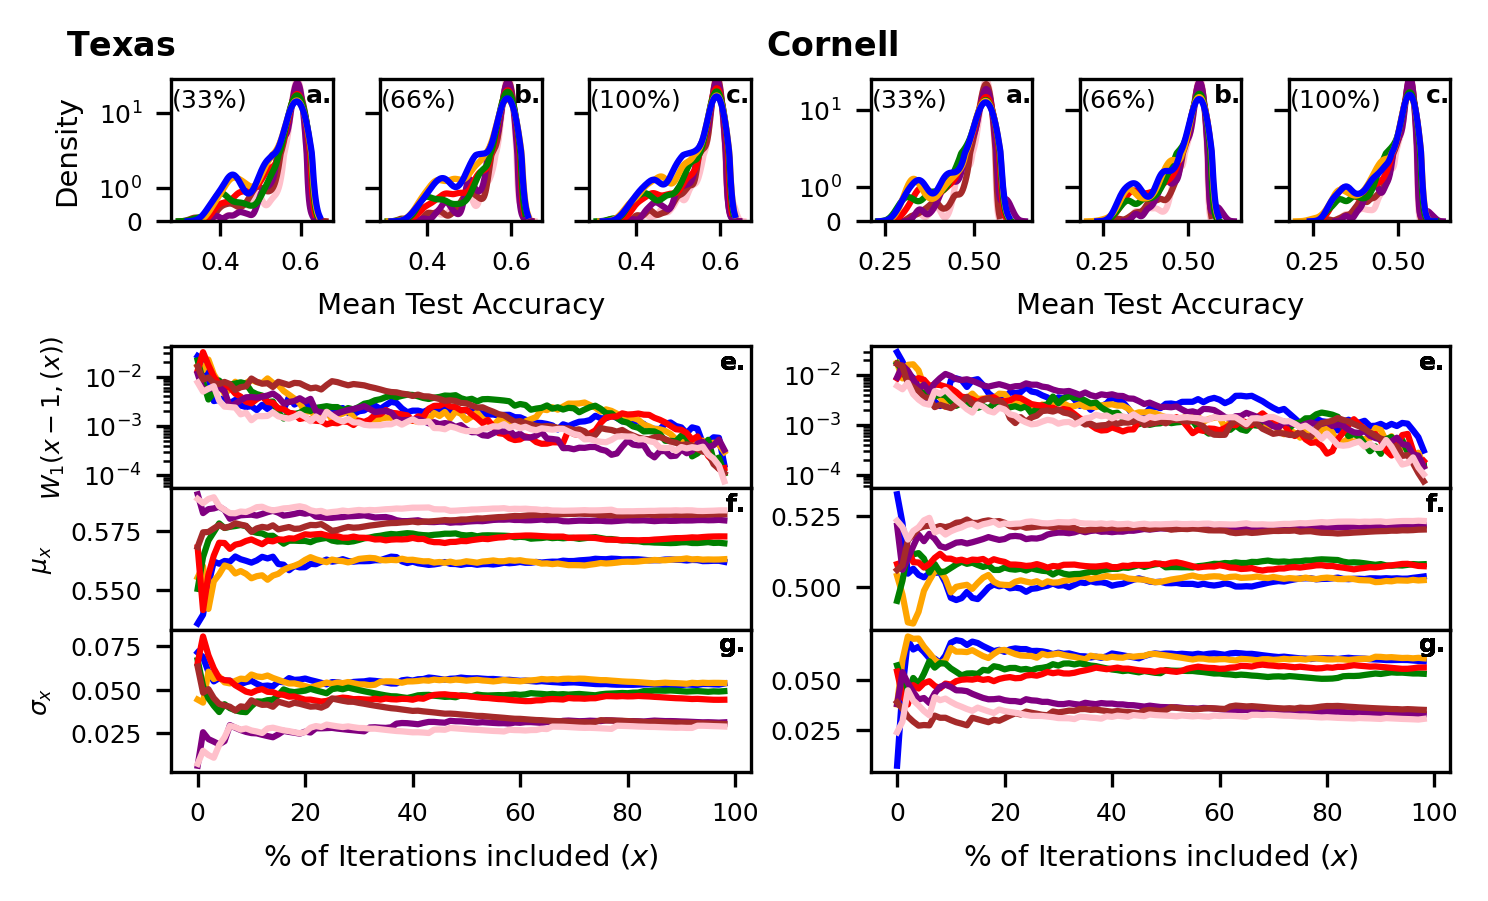

In [87]:
draw_distribution_analysis(["Texas","Cornell"])

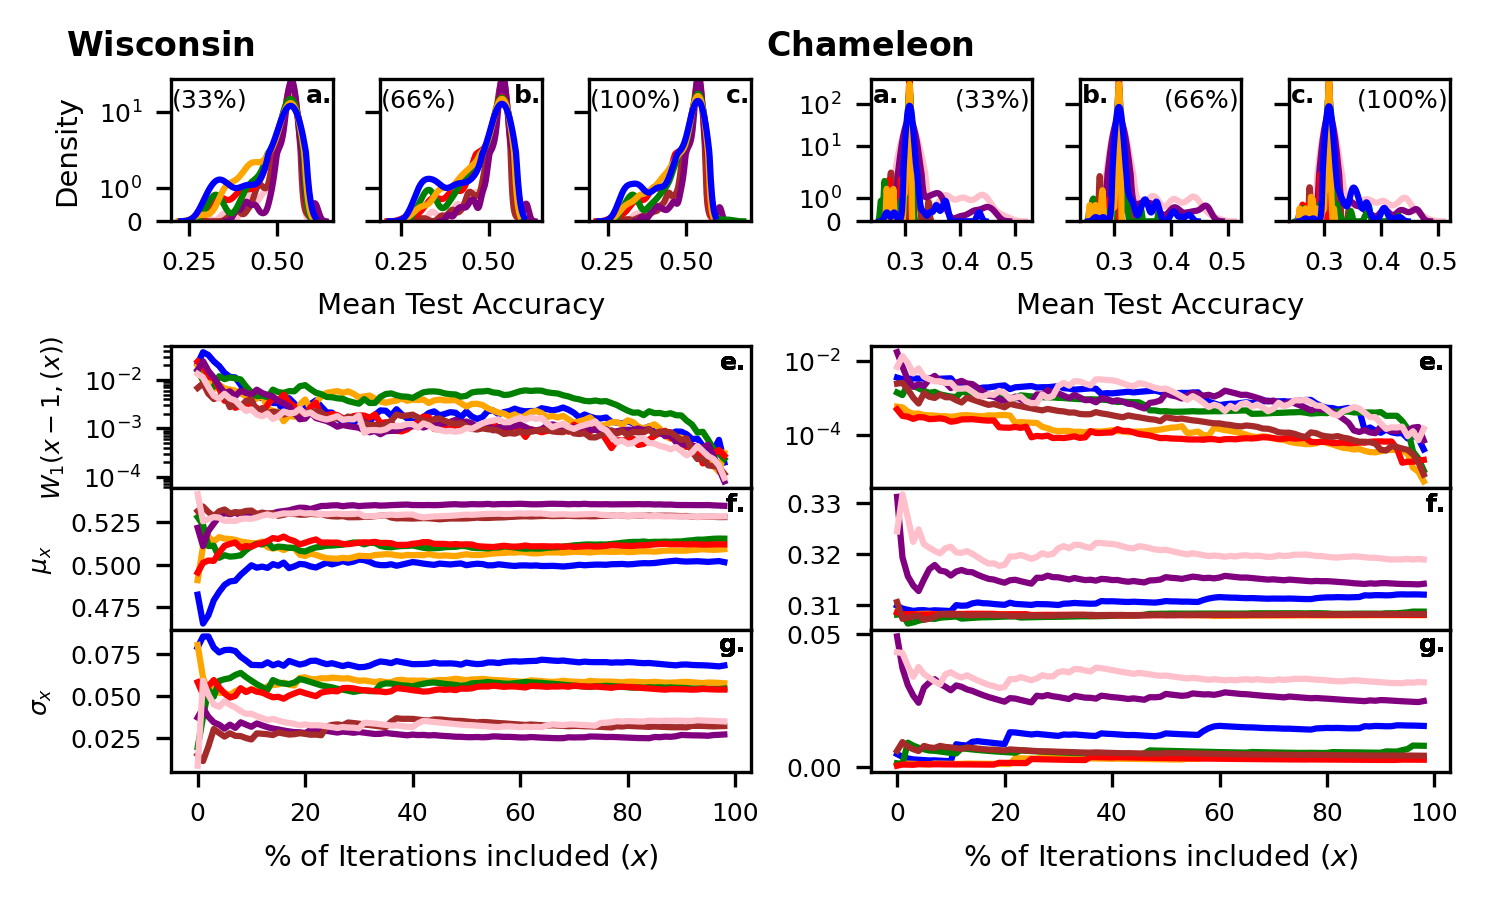

In [83]:
draw_distribution_analysis(["Wisconsin","Chameleon"])

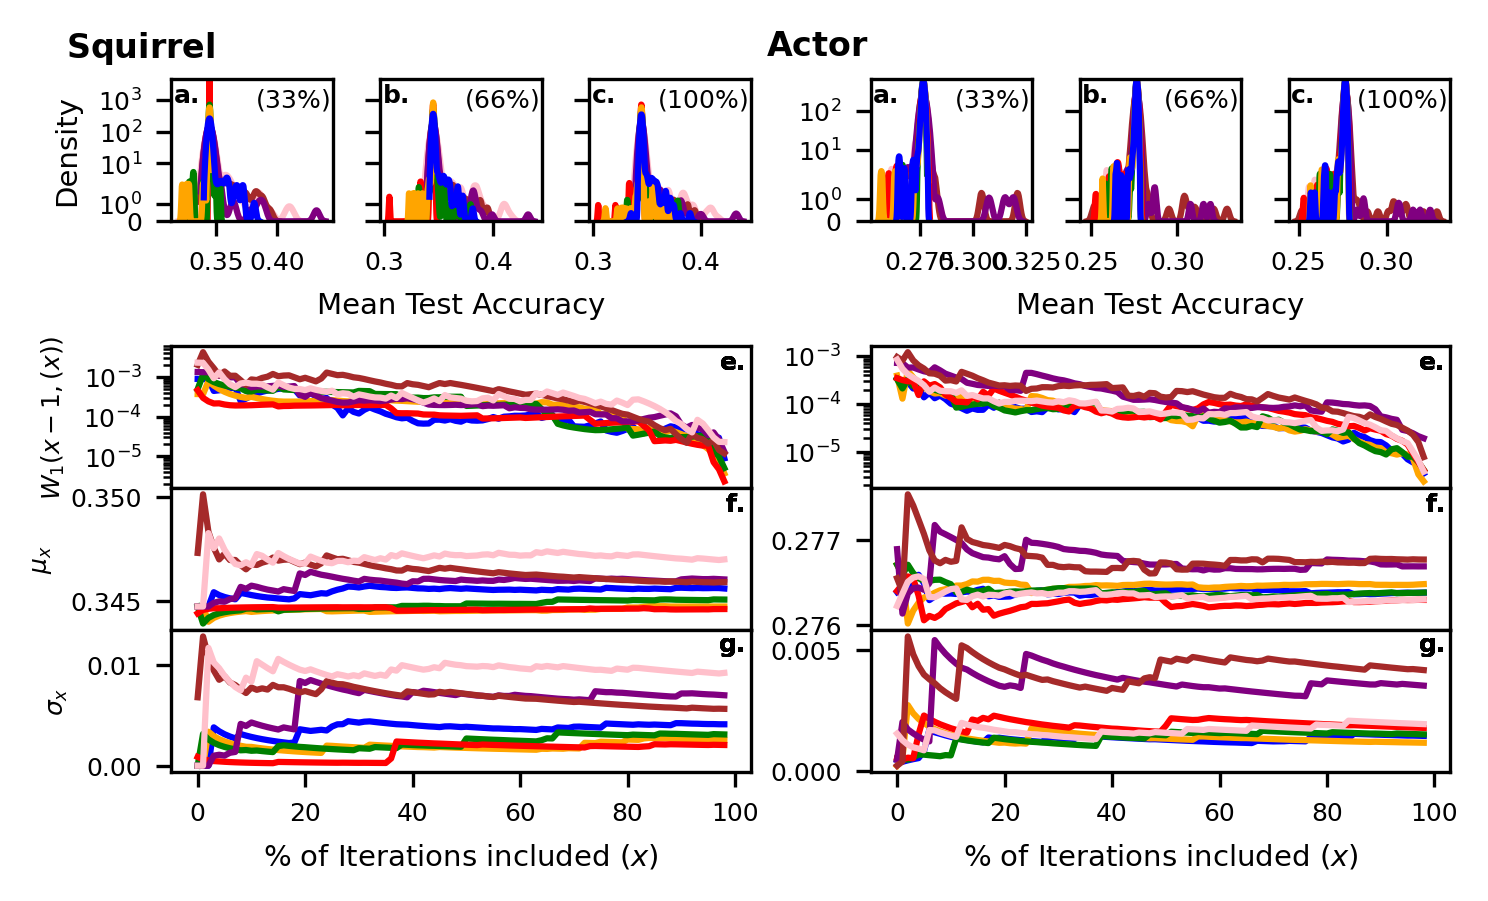

In [84]:
draw_distribution_analysis(["Squirrel","Actor"])

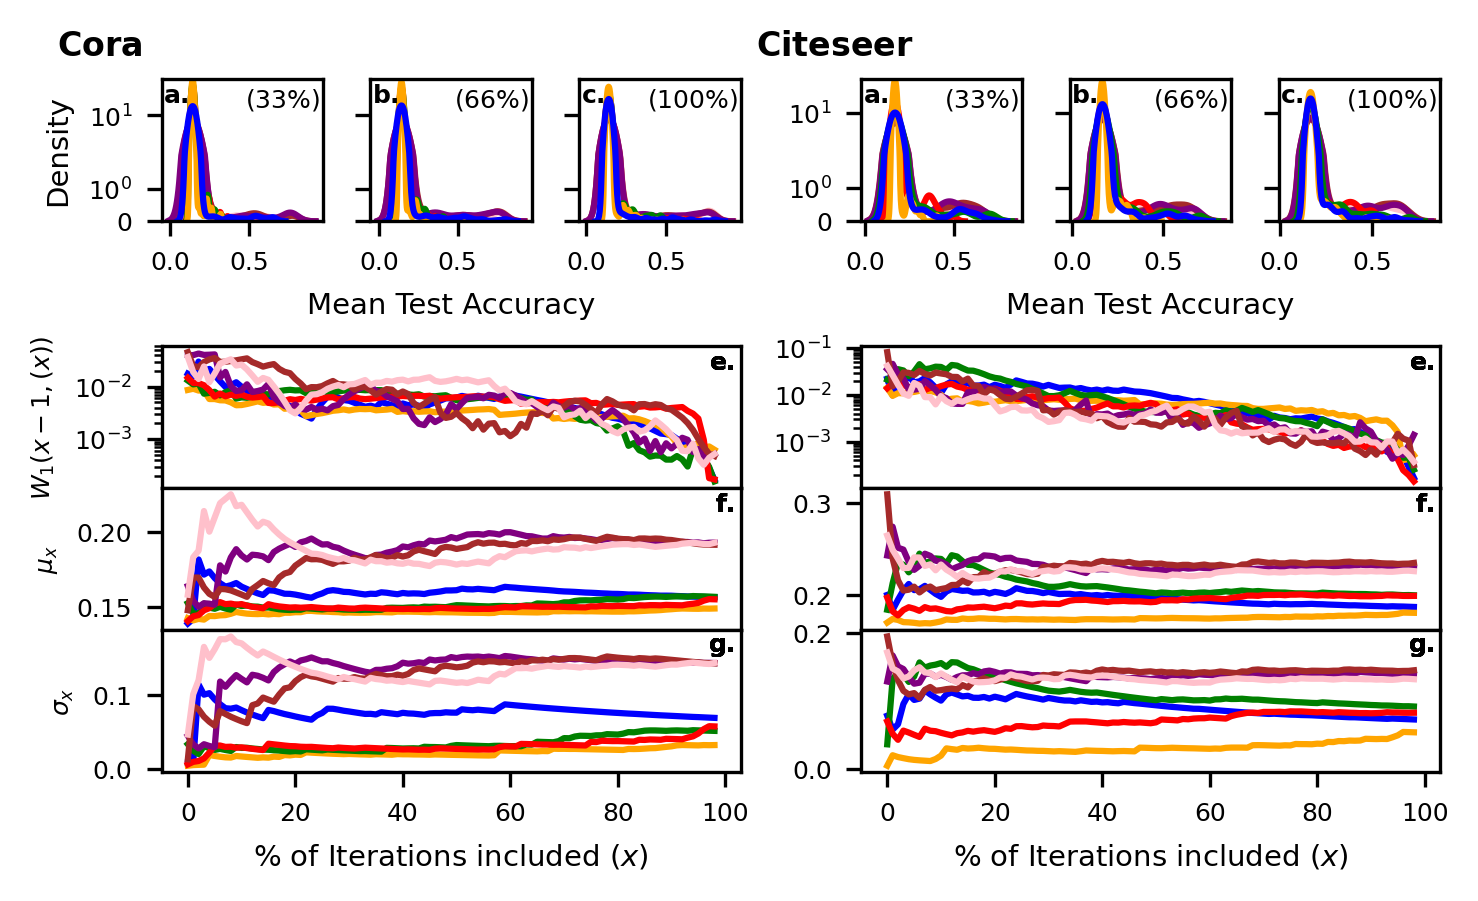

In [85]:
draw_distribution_analysis(["Cora","Citeseer"])

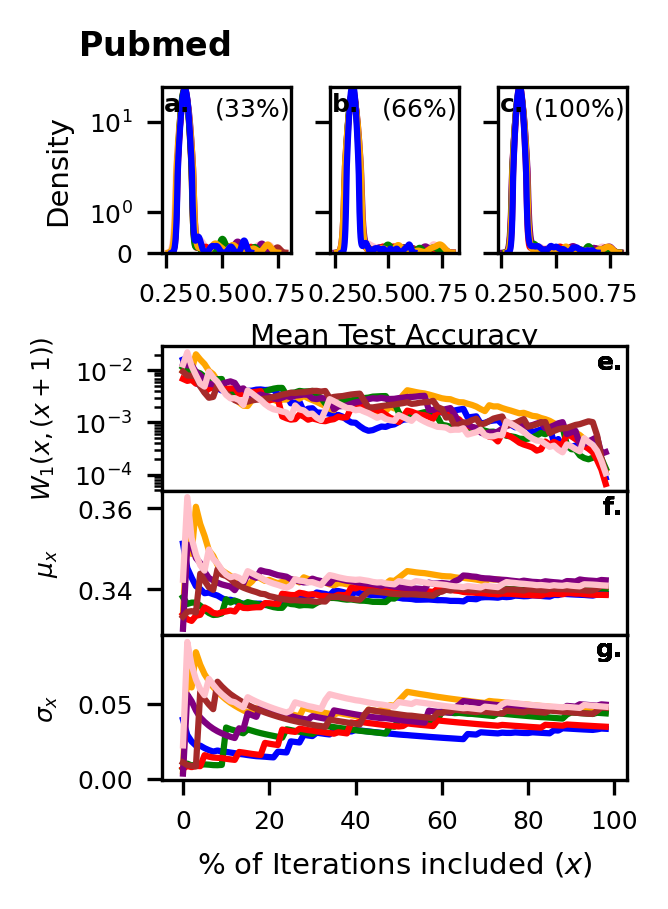

In [106]:
draw_distribution_analysis_single("Pubmed")

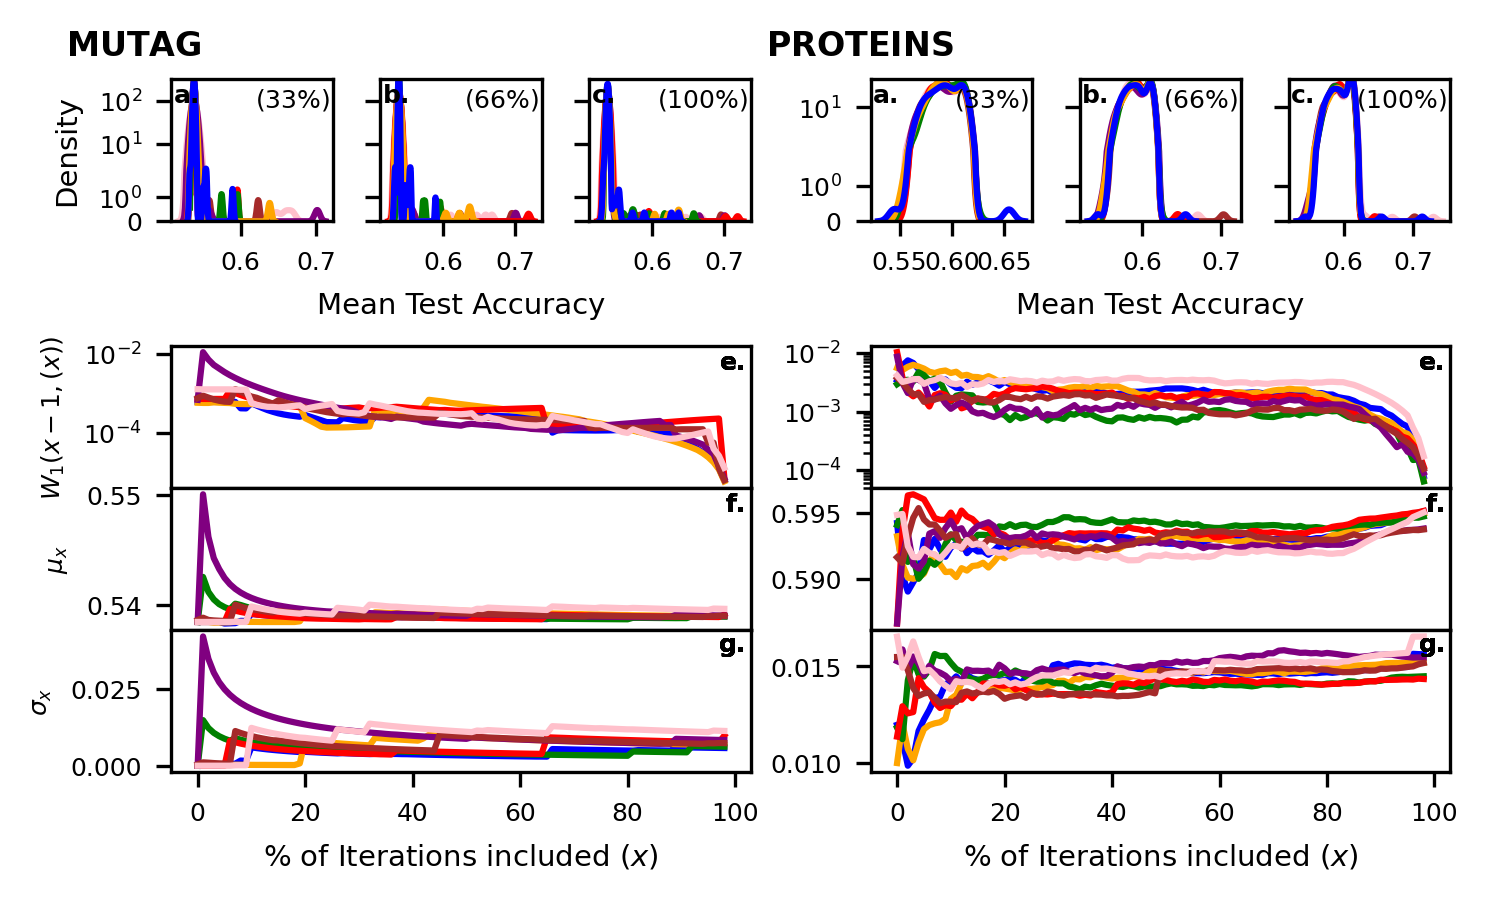

In [134]:
draw_distribution_analysis(["MUTAG","PROTEINS"])

## Individual Datasets figures

### Function

In [42]:
def individual_dataset_figure(dataset,dataset_name):

    figIndividual_Tx,axIndividual_Tx = plt.subplot_mosaic([['BP','.','Dens'],['BP','.','.']],figsize = (5.5,2),dpi = 200,
                                gridspec_kw = {'width_ratios': [1,0.05,1] ,'height_ratios': [1,1]})

    figIndividual_Tx.suptitle(dataset_name,fontsize = 11)

    #_ = axIndividual_Tx['Dens'].plot([1/5,1/5],[0,70],':',color = 'grey',label = 'Random accuracy')

    _ = sns.kdeplot(data = dataset["BFc_w4cycle"],ax = axIndividual_Tx['Dens'],color = 'blue',legend=False)
    _ = sns.kdeplot(data = dataset["BFc_no4cycle"], ax = axIndividual_Tx['Dens'],color = 'orange',legend=False)
    _ = sns.kdeplot(data = dataset["BFc_mod"], ax = axIndividual_Tx['Dens'],color = 'green',legend=False)
    _ = sns.kdeplot(data = dataset["JLc"], ax = axIndividual_Tx['Dens'],color = 'red',legend=False)
    _ = sns.kdeplot(data = dataset["AFc_3"], ax = axIndividual_Tx['Dens'],color = 'purple',legend=False)
    _ = sns.kdeplot(data = dataset["AFc_4"], ax = axIndividual_Tx['Dens'],color = 'brown',legend=False)
    _ = sns.kdeplot(data = dataset["None"],ax = axIndividual_Tx['Dens'],color = 'pink',legend=False)



    _ = sns.boxenplot(data = dataset,ax = axIndividual_Tx['BP'],orient = "y",palette=palette_colors_curvature,legend=False)

    #_ = axIndividual_Tx['BP'].plot([1/5,1/5],[0,7],':',color = 'grey',label = 'Random accuracy')
    
    axIndividual_Tx['BP'].set_xlabel("Mean accuracy",fontsize = 7)
    axIndividual_Tx['BP'].set_yticks([0,1,2,3,4,5,6],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$","None"])

    axIndividual_Tx['Dens'].set_xlabel("Mean accuracy",fontsize = 7)
    axIndividual_Tx['Dens'].set_ylabel("Density",fontsize = 7)
    axIndividual_Tx['Dens'].set_yscale("symlog")
    for axlabel in axIndividual_Tx:
        axIndividual_Tx[axlabel].tick_params(labelsize = 6)

### Results

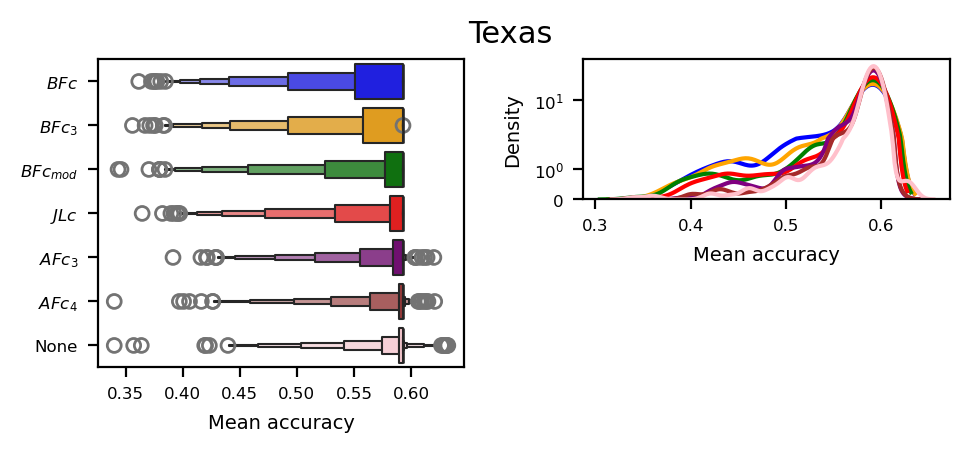

In [43]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Texas"],"Texas")

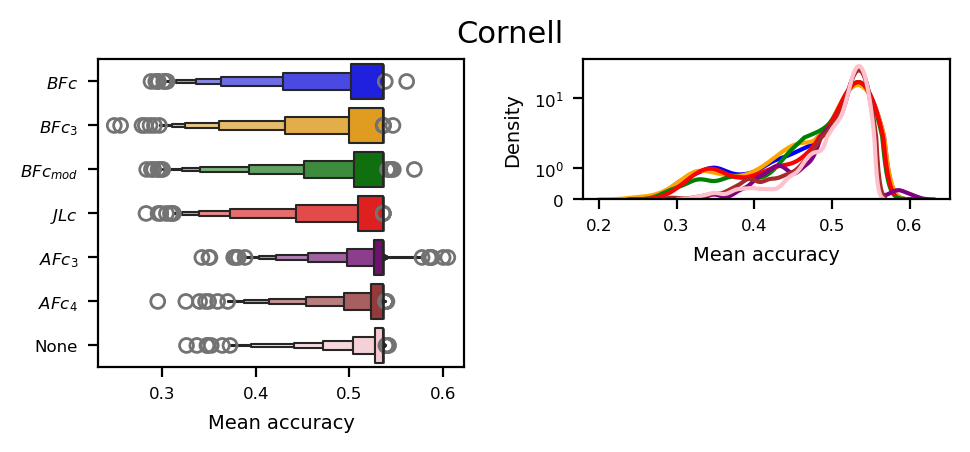

In [44]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Cornell"],"Cornell")

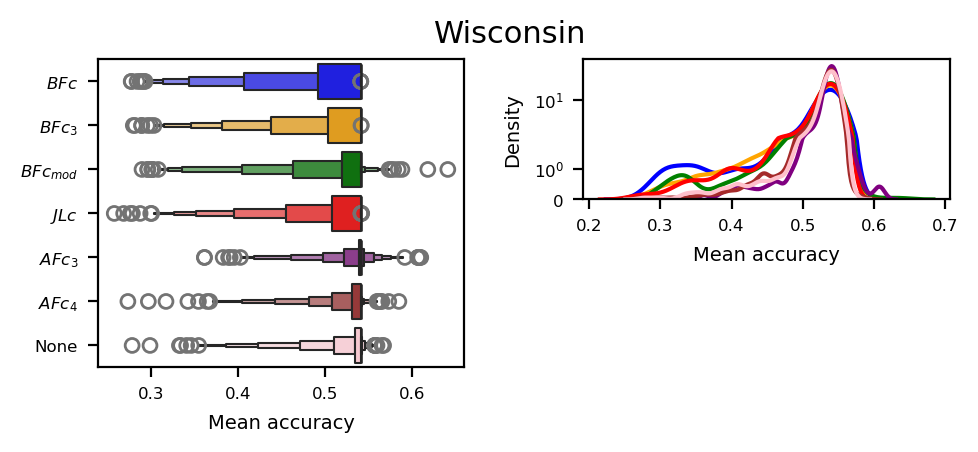

In [45]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Wisconsin"],"Wisconsin")

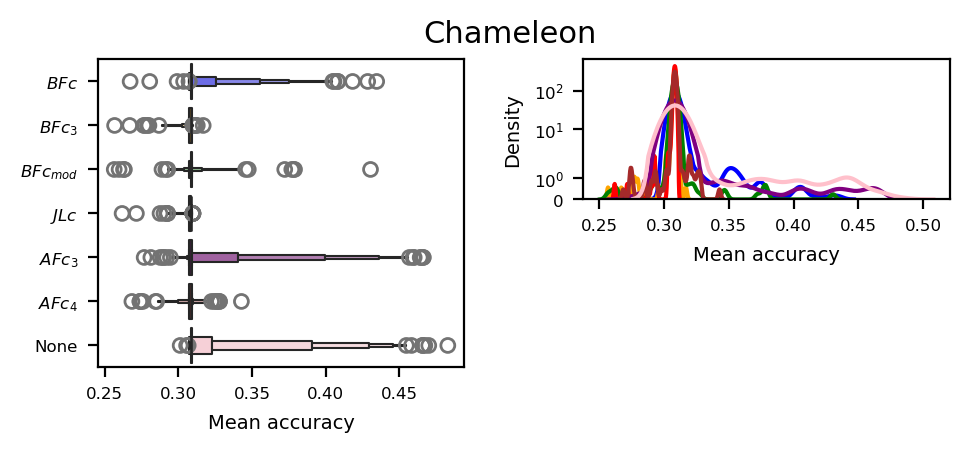

In [46]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Chameleon"],"Chameleon")

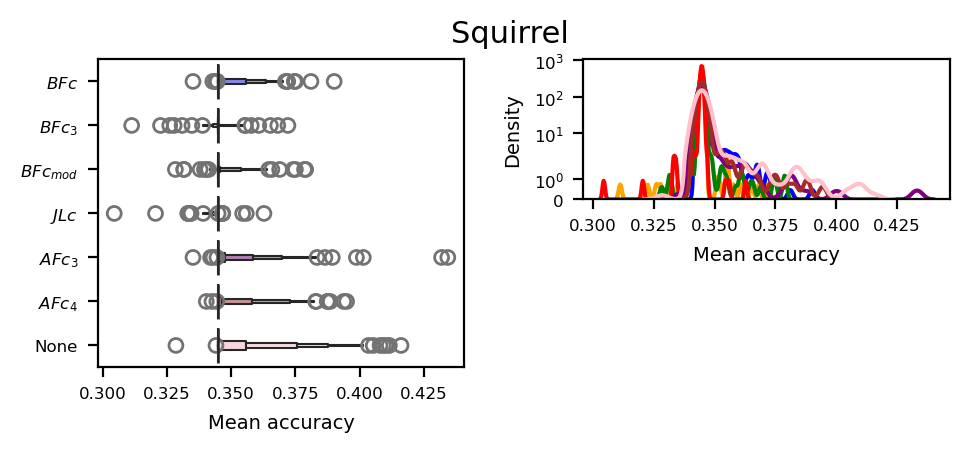

In [47]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Squirrel"],"Squirrel")

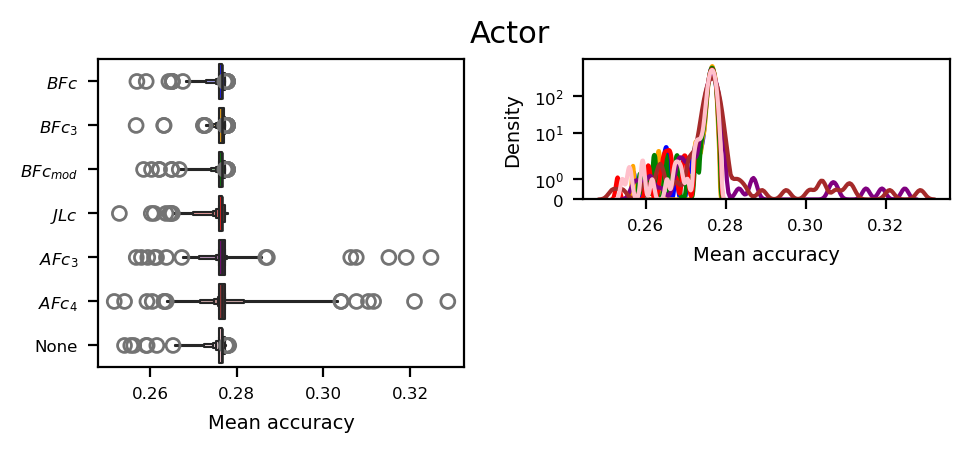

In [48]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Actor"],"Actor")

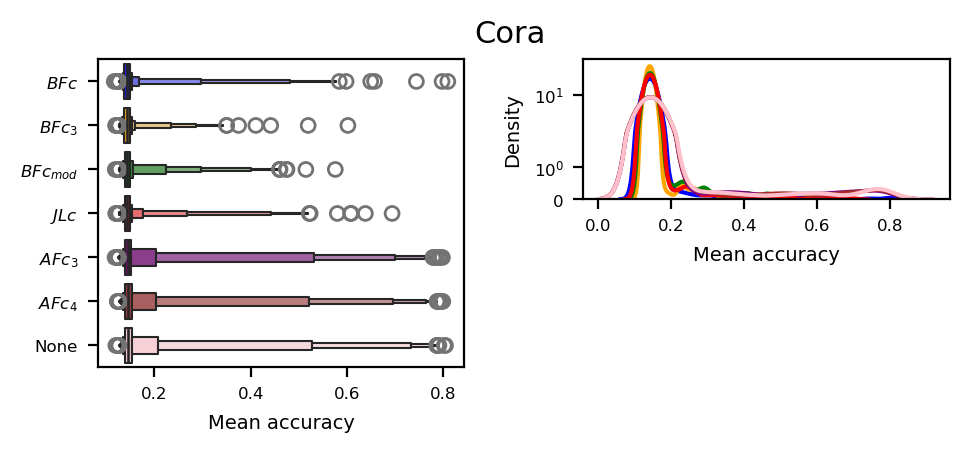

In [49]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Cora"],"Cora")

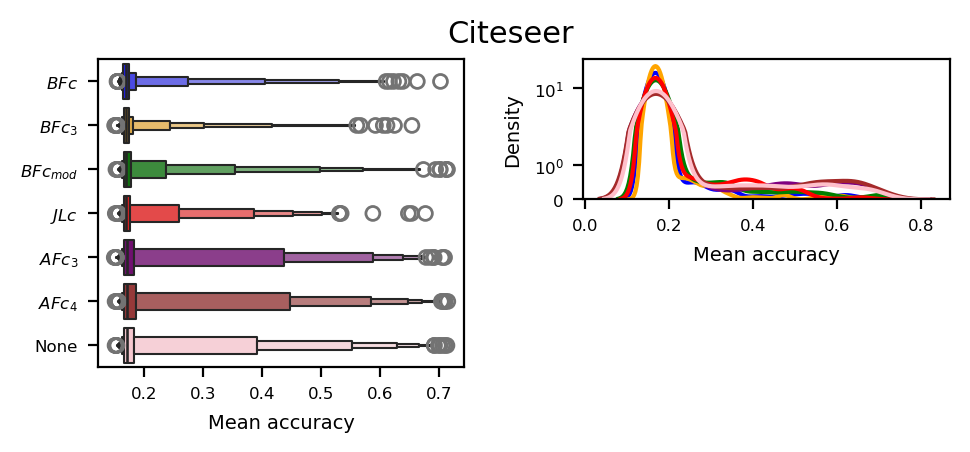

In [50]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Citeseer"],"Citeseer")

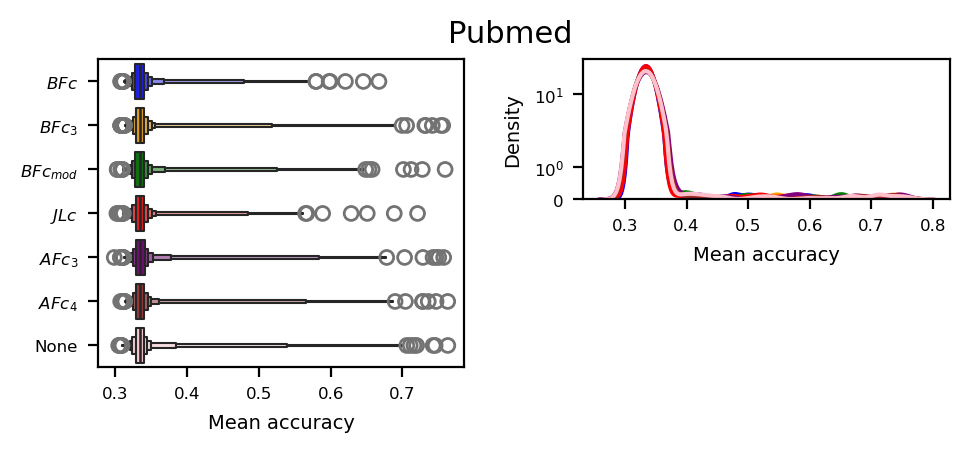

In [51]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["Pubmed"],"Pubmed")

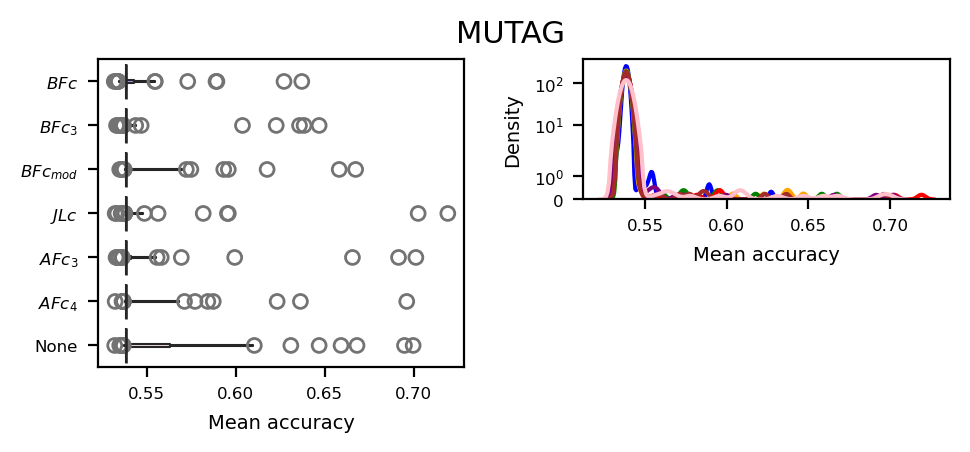

In [52]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["MUTAG"],"MUTAG")

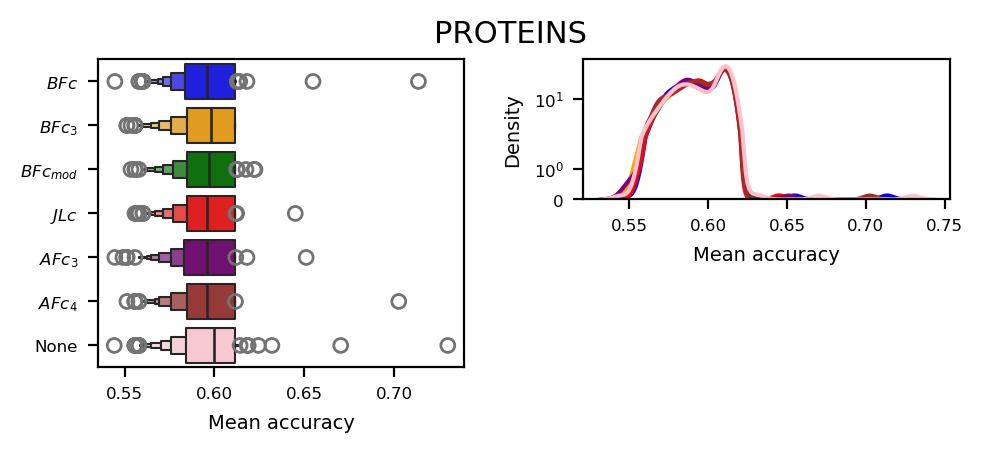

In [53]:
individual_dataset_figure(dict_classification_datasets_meanaccuracy["PROTEINS"],"PROTEINS")

# Fixed Hyperparameter Analysis

In [73]:
dataset_names_fp = ['Texas']
curvature_types_fp = ['BFc_w4cycle','BFc_no4cycle','BFc_mod','JLc','AFc_3','AFc_4','None']

In [84]:
dict_classification_datasets_fp = {}
dict_classification_datasets_meanaccuracy_fp = {}
dict_classification_datasets_meanaccuracy_loops_fp = {}

for dataset_name in dataset_names_fp:
    dictionary_dataset_fp = {}
    dictionary_dataset_meanaccuracy_fp = {}
    dictionary_dataset_meanaccuracy_loops_fp = {}

    for curvature_type in curvature_types_fp:
        dataset = pd.read_csv(f"{path_load}/{dataset_name}_{curvature_type}_fixedTopping.csv",nrows = 190)
        dictionary_dataset_fp[curvature_type] = dataset

        mean_accuracy = dataset['mean test accuracy']
        dictionary_dataset_meanaccuracy_fp[curvature_type] = mean_accuracy

        mean_accuracy_loops = dataset[['mean test accuracy','loops']]
        dictionary_dataset_meanaccuracy_loops_fp[curvature_type] = mean_accuracy_loops



    dict_classification_datasets_fp[dataset_name] = dictionary_dataset_fp
    dict_classification_datasets_meanaccuracy_fp[dataset_name] = dictionary_dataset_meanaccuracy_fp
    dict_classification_datasets_meanaccuracy_loops_fp[dataset_name] = dictionary_dataset_meanaccuracy_loops_fp


In [87]:
def hyperparameter_density_plot_fp(dataset_name):

    figTotal, axTotal = plt.subplot_mosaic([['Dens','Dens','Dens'],
                                            ['BP','BP','BP']],figsize = (3.14961,3.14961+1.1811),dpi = 200,
                                gridspec_kw = {'width_ratios': [0.5,0.01,0.5] ,'height_ratios': [1,1],'hspace': 0})
    #6 op 8 cm

    right = 0.98
    top = 1.15
    left = 0.0


    #if dataset_name in ["Texas","Cornell","Wisconsin"]:
    axTotal[f'Dens'].text(left, top,
                            horizontalalignment='left',
                            verticalalignment='top',
                            transform=axTotal[f'Dens'].transAxes,s = r"$\mathbf{"+dataset_name+"}$",fontsize = 16)


    flierprops = dict(marker='D',  linewidth = 0.5,edgecolor='black',s = 10)

    _ = sns.kdeplot(data = dict_classification_datasets_meanaccuracy_fp[dataset_name],ax = axTotal[f'Dens'],
                    palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'},
                    legend=False,common_norm=False,log_scale=(False,True),
                    linewidth = 2.5)
    
    _ = sns.boxenplot(data = dict_classification_datasets_meanaccuracy_fp[dataset_name],ax = axTotal[f'BP']
                      ,orient = "y",palette= {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'}
                      ,legend=False,
                      flier_kws = flierprops,box_kws = {'linewidth':0.4})
    
    [i.set_linewidth(2) for i in axTotal['Dens'].spines.values()]
    [i.set_linewidth(2) for i in axTotal['BP'].spines.values()]

    axTotal['Dens'].set_xlabel("",fontsize = 12)

    axTotal['Dens'].set_ylabel("Density",fontsize = 16)
    axTotal['BP'].set_xlabel("Accuracy",fontsize = 16)
    #labels = [r"$" + curvature + "$" for curvature in curvature_types]
    axTotal['BP'].set_yticks([*range(7)],[r"$BFc$",r"$BFc_3$",r"$BFc_{mod}$",r"$JLc$",r"$AFc_3$",r"$AFc_4$",r"$None$"])

    axTotal['Dens'].set_yscale("symlog")
    
    axTotal['Dens'].tick_params(labelsize = 12)
    axTotal['BP'].tick_params(labelsize = 12)
    

    _ = axTotal['BP'].sharex(axTotal['Dens'])   
    _ = [label.set_visible(False) for label in axTotal['Dens'].get_xticklabels()]     


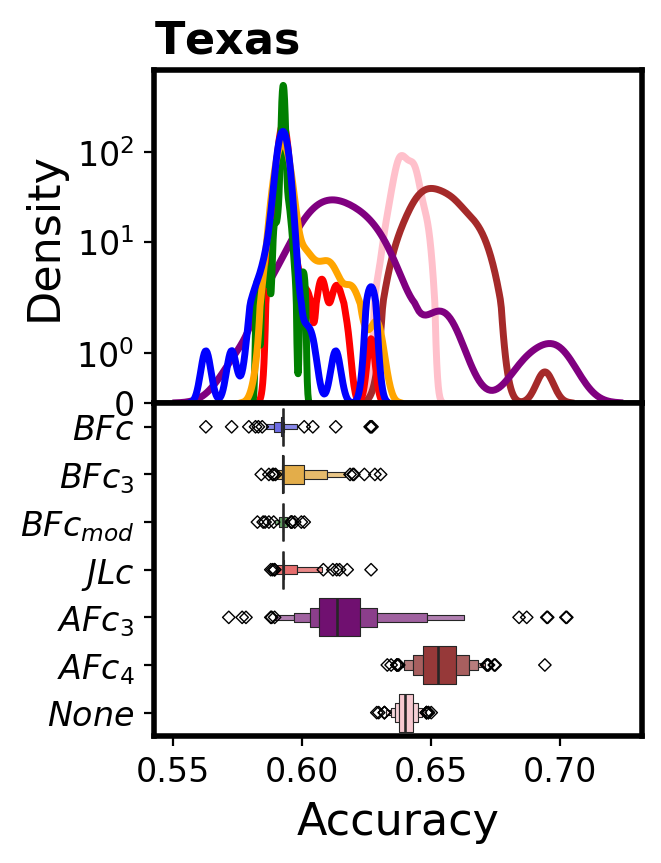

In [88]:
hyperparameter_density_plot_fp("Texas")

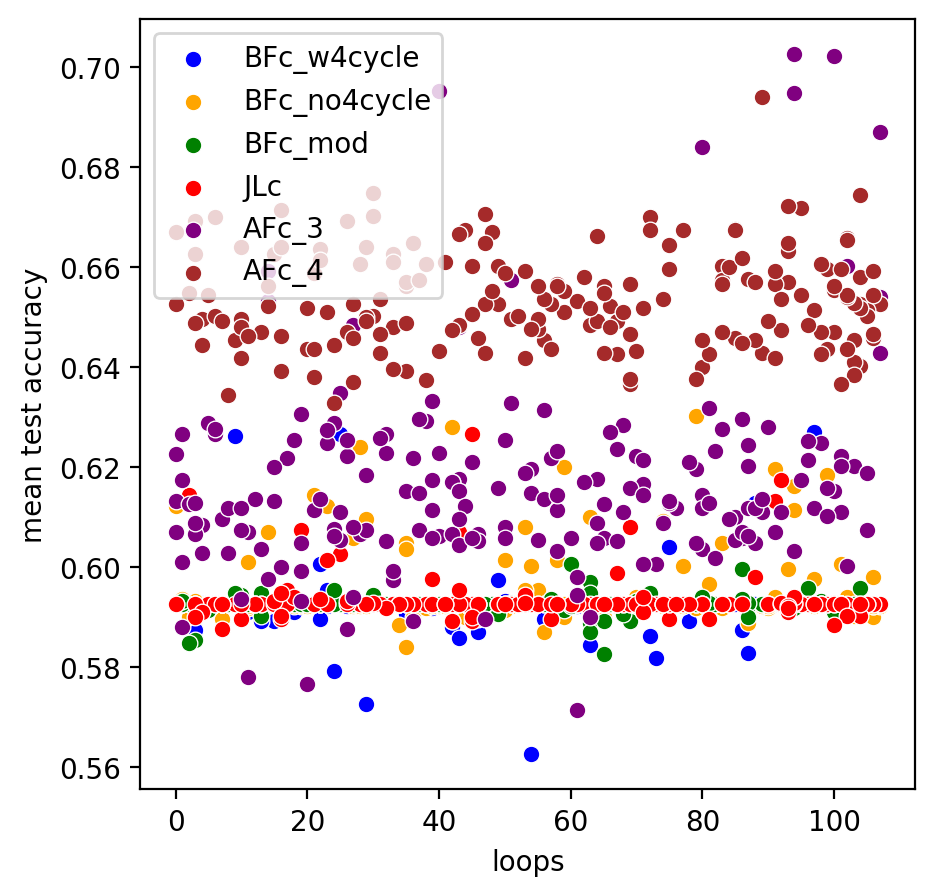

In [91]:
fig,ax = plt.subplots(1,1,figsize = (5,5),dpi = 200)

colors_fp = {'BFc_w4cycle':'blue','BFc_no4cycle':'orange','BFc_mod':'green','JLc':'red','AFc_3':'purple','AFc_4':'brown','None':'pink'}
for curvature_type in curvature_types_fp[:-1]:
    sns.scatterplot(data = dict_classification_datasets_fp["Texas"][curvature_type],y = "mean test accuracy",x = "loops",color = colors_fp[curvature_type],ax = ax,label = curvature_type)
#sns.scatterplot(data = dict_classification_datasets_fp["Texas"]["BFc_no4cycle"],y = "mean test accuracy",x = "loops")
#sns.scatterplot(data = dict_classification_datasets_fp["Texas"]["AFc_3"],y = "mean test accuracy",x = "loops")
#sns.scatterplot(data = dict_classification_datasets_fp["Texas"]["AFc_4"],y = "mean test accuracy",x = "loops")


<Axes: xlabel='loops', ylabel='mean test accuracy'>

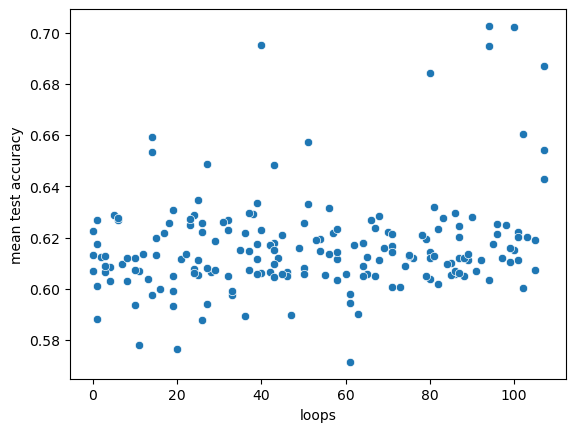

In [65]:
sns.scatterplot(data = dict_classification_datasets_meanaccuracy_fp["Texas"]["AFc_3"],y = "mean test accuracy",x = "loops")